# EDA — Football Data Lake: tầng Gold `features`

Notebook thực hiện **Exploratory Data Analysis (EDA)** chi tiết cho 8 bảng `feature_*` ở tầng **Gold**
(`gold/features/` trên MinIO), phục vụ các bài toán Machine Learning bóng đá (dự đoán kết quả trận đấu,
tổng bàn thắng, BTTS...).

**Mục lục**

1. Kết nối MinIO & đọc dữ liệu
2. Tổng quan Feature Catalog
3. EDA bảng chính `feature_match_ml` (khóa, split, biến mục tiêu)
4. Phân tích missing values
5. EDA nhóm Elo
6. EDA nhóm Market Odds (thị trường cược)
7. EDA nhóm xG (Expected Goals)
8. EDA nhóm Form (phong độ đội)
9. EDA nhóm Position (vị trí BXH trước trận)
10. EDA nhóm Context (thời gian, thời tiết)
11. EDA nhóm Attention (lượt xem Wikipedia)
12. Ma trận tương quan tổng thể & đa cộng tuyến
13. So sánh sức mạnh dự đoán: Market vs Elo vs Form
14. Phân tích theo đội bóng (team-level, dùng bảng theo trận)
15. Phân tích bảng xếp hạng theo thời gian
16. Data Quality Summary & khuyến nghị
17. Kết luận

> **Lưu ý chống rò rỉ (leakage):** theo thiết kế pipeline, feature của trận `T` chỉ dùng dữ liệu
> (ngày, match_id) **trước** trận `T`. Notebook này chỉ quan sát/kiểm tra dữ liệu, không thay đổi logic tạo feature.


## 1. Cài đặt môi trường & kết nối MinIO

In [1]:
# [DÀNH RIÊNG CHO GOOGLE COLAB]
import sys, os
os.environ['MINIO_ENDPOINT'] = 'http://20.41.113.183:9000'
os.environ['MINIO_ACCESS_KEY'] = 'minioadmin'
os.environ['MINIO_SECRET_KEY'] = 'minioadmin123'
if 'SEED_PATH' in os.environ: del os.environ['SEED_PATH']
if 'google.colab' in sys.modules:
    !rm -rf /content/Lab
    !git clone -b feat-e https://github.com/nbngoc123/Lab.git /content/Lab
    os.chdir('/content/Lab/football-lake')
    sys.path.insert(0, '/content/Lab/football-lake')
    !pip install minio duckdb pandas understatapi boto3 python-dotenv -q
    print('Setup xong Colab!')


Cloning into '/content/Lab'...
remote: Enumerating objects: 873, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 873 (delta 0), reused 2 (delta 0), pack-reused 866 (from 1)
Receiving objects: 100% (873/873), 71.74 MiB | 34.06 MiB/s, done.
Resolving deltas: 100% (422/422), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 537.7/537.7 kB 10.0 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.4/159.4 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.1/153.1 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# Thư viện phục vụ EDA (cài thêm nếu môi trường chưa có)
!pip install matplotlib seaborn scipy statsmodels -q

import io
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

RANDOM_STATE = 42


### 1.1. Đọc dữ liệu `gold/features/*`

Dùng lại helper `lake.minio_io` sẵn có trong repo (client S3 path-style cho MinIO).
Nếu không kết nối được MinIO (chạy offline / đã tải sẵn thư mục `features/` cạnh notebook — ví dụ
export từ `features.zip`), code sẽ **tự động fallback** sang đọc file local.

In [3]:
GOLD_PREFIX = "gold/features"

FEATURE_TABLES = [
    "feature_team_match",
    "feature_league_position",
    "feature_elo",
    "feature_market",
    "feature_team_xg",
    "feature_team_attention",
    "feature_match_context",
    "feature_match_ml",
]

def load_from_minio():
    """Đọc toàn bộ bảng feature_* + catalog từ MinIO (gold/features/)."""
    from lake import minio_io as mio
    tables = {}
    for name in FEATURE_TABLES:
        key = f"{GOLD_PREFIX}/{name}.parquet"
        data = mio.read_bytes(key)
        tables[name] = pd.read_parquet(io.BytesIO(data))
        print(f"  ok {name:<28} {tables[name].shape}")
    catalog_key = f"{GOLD_PREFIX}/_feature_catalog.csv"
    catalog = pd.read_csv(io.BytesIO(mio.read_bytes(catalog_key)))
    return tables, catalog


def load_from_local(root="features"):
    """Fallback: đọc từ thư mục local đã export sẵn (feature_*.parquet + _feature_catalog.csv)."""
    from pathlib import Path
    root = Path(root)
    tables = {}
    for name in FEATURE_TABLES:
        tables[name] = pd.read_parquet(root / f"{name}.parquet")
        print(f"  ok {name:<28} {tables[name].shape}  (local)")
    catalog = pd.read_csv(root / "_feature_catalog.csv")
    return tables, catalog


try:
    print("Dang doc du lieu tu MinIO (gold/features/)...")
    tables, catalog = load_from_minio()
    print("\nDa doc thanh cong tu MinIO.")
except Exception as e:
    print(f"Khong doc duoc tu MinIO ({e}).\nFallback: doc local thu muc './features'...")
    tables, catalog = load_from_local("features")
    print("\nDa doc thanh cong tu local.")

# Gan bien rieng cho tung bang cho de thao tac
team_match = tables["feature_team_match"]
league_pos = tables["feature_league_position"]
elo        = tables["feature_elo"]
market     = tables["feature_market"]
team_xg    = tables["feature_team_xg"]
team_att   = tables["feature_team_attention"]
match_ctx  = tables["feature_match_context"]
match_ml   = tables["feature_match_ml"]


Dang doc du lieu tu MinIO (gold/features/)...
  ok feature_team_match           (1520, 27)
  ok feature_league_position      (1520, 7)
  ok feature_elo                  (760, 5)
  ok feature_market               (760, 9)
  ok feature_team_xg              (1520, 10)
  ok feature_team_attention       (1520, 6)
  ok feature_match_context        (760, 9)
  ok feature_match_ml             (760, 126)

Da doc thanh cong tu MinIO.


## 2. Tổng quan Feature Catalog

`_feature_catalog.csv` cho biết mỗi cột trong `feature_match_ml` thuộc **nhóm feature** nào
(`key`, `form`, `position`, `elo`, `market`, `xg`, `attention`, `context`, `target`).
Nắm được nhóm này giúp việc phân tích và chọn feature cho model có hệ thống hơn.

Tổng số cột trong feature_match_ml: 126


,so_cot
feature_group,
form,50
xg,19
position,12
key,10
attention,9
context,8
market,8
target,6
elo,4


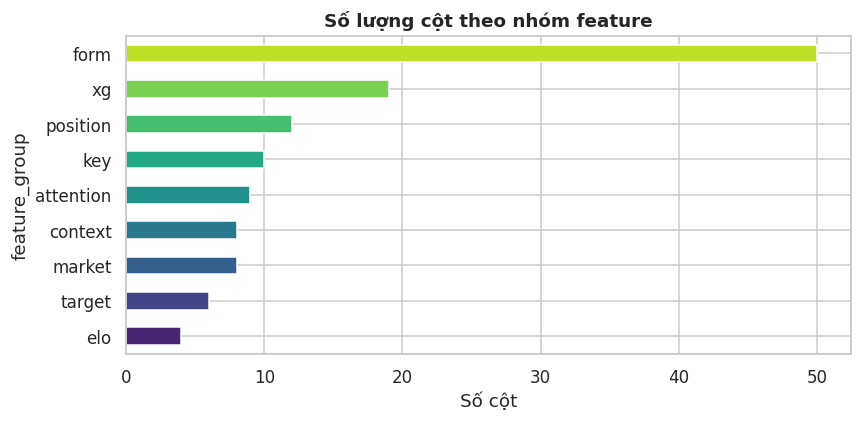

In [4]:
print(f"Tổng số cột trong feature_match_ml: {len(catalog)}")
group_counts = catalog["feature_group"].value_counts()
display(group_counts.to_frame("so_cot"))

fig, ax = plt.subplots(figsize=(8, 4))
group_counts.sort_values().plot(kind="barh", ax=ax, color=sns.color_palette("viridis", len(group_counts)))
ax.set_title("Số lượng cột theo nhóm feature")
ax.set_xlabel("Số cột")
plt.tight_layout()
plt.show()


In [5]:
# Kiểm tra khớp giữa catalog và cột thực tế của feature_match_ml
catalog_cols = set(catalog["column_name"])
actual_cols = set(match_ml.columns)

missing_in_catalog = actual_cols - catalog_cols
missing_in_data = catalog_cols - actual_cols

print("Cột có trong data nhưng thiếu trong catalog:", missing_in_catalog or "Không có")
print("Cột có trong catalog nhưng thiếu trong data:", missing_in_data or "Không có")


Cột có trong data nhưng thiếu trong catalog: Không có
Cột có trong catalog nhưng thiếu trong data: Không có


## 3. EDA bảng chính `feature_match_ml`

Đây là bảng **1 dòng / 1 trận đấu**, gộp toàn bộ nhóm feature + các cột `target_*` — bảng trung tâm để
huấn luyện model.

In [6]:
print("Shape:", match_ml.shape)
match_ml.info(verbose=False, memory_usage="deep")


Shape: (760, 126)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 760 entries, 0 to 759
Columns: 126 entries, match_id to target_btts
dtypes: Int32(3), Int64(3), datetime64[us](1), float64(92), int32(5), int64(13), object(9)
memory usage: 1.0 MB


In [7]:
display(match_ml.head(5))


,match_id,division,season,match_date,home_key,away_key,home_team,away_team,split,is_warm,home_n_prior,home_n_prior_season,home_rest_days,home_pts_l5,home_gf_l5,home_ga_l5,home_sot_l5,home_sot_against_l5,home_shots_l5,home_corners_l5,home_cards_l5,home_win_l5,home_cs_l5,home_pts_l10,home_gf_l10,home_ga_l10,home_pts_l5_venue,home_gf_l5_venue,home_ga_l5_venue,home_ppg_season,home_gd_pg_season,away_n_prior,away_n_prior_season,away_rest_days,away_pts_l5,away_gf_l5,away_ga_l5,away_sot_l5,away_sot_against_l5,away_shots_l5,away_corners_l5,away_cards_l5,away_win_l5,away_cs_l5,away_pts_l10,away_gf_l10,away_ga_l10,away_pts_l5_venue,away_gf_l5_venue,away_ga_l5_venue,away_ppg_season,away_gd_pg_season,diff_pts_l5,diff_gf_l5,diff_ga_l5,diff_sot_l5,diff_pts_l10,diff_ppg_season,diff_gd_pg_season,diff_pts_l5_venue,home_played_before,home_points_before,home_gd_before,home_rank_before,home_is_top6,away_played_before,away_points_before,away_gd_before,away_rank_before,away_is_top6,rank_diff,points_diff,elo_home,elo_away,elo_diff,elo_exp_home,mkt_p_home,mkt_p_draw,mkt_p_away,mkt_margin,mkt_n_books,pin_p_home,pin_p_draw,pin_p_away,home_xg_l5,home_xga_l5,home_npxg_l5,home_xgd_l5,home_ppda_l5,home_xg_l10,home_xga_l10,home_xg_overperf_l10,away_xg_l5,away_xga_l5,away_npxg_l5,away_xgd_l5,away_ppda_l5,away_xg_l10,away_xga_l10,away_xg_overperf_l10,diff_xg_l5,diff_xga_l5,diff_xgd_l5,home_pv_7d,home_pv_28d,home_pv_last1,home_pv_ratio_7_28,away_pv_7d,away_pv_28d,away_pv_last1,away_pv_ratio_7_28,diff_pv_ratio_7_28,kickoff_hour,dow,month,is_weekend,temp_c,precip_mm,wind_kmh,is_raining,target,target_home_goals,target_away_goals,target_total_goals,target_over25,target_btts
0,E0_2024-25_20240816_ManUnited_Fulham,E0,2024-25,2024-08-16,Manchester United,Fulham,Man United,Fulham,valid,0,0,0,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,0.0,<NA>,<NA>,0,0.0,0.0,<NA>,<NA>,<NA>,0.0,1500.0,1500.0,0.0,0.592466,0.592094,0.223382,0.184524,0.042741,4.0,0.595347,0.221556,0.183097,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25329.857143,16799.964286,21598.0,1.507733,3758.714286,3285.000000,5345.0,1.144205,0.363528,20,5,8,0,NaN,NaN,NaN,<NA>,H,1,0,1,0,0
1,E0_2024-25_20240817_Arsenal_Wolves,E0,2024-25,2024-08-17,Arsenal,Wolverhampton,Arsenal,Wolves,valid,0,0,0,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,0.0,<NA>,<NA>,0,0.0,0.0,<NA>,<NA>,<NA>,0.0,1500.0,1500.0,0.0,0.592466,0.809543,0.125652,0.064805,0.047034,4.0,0.828479,0.112271,0.059250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10531.142857,9289.571429,12560.0,1.133652,4026.142857,2882.214286,5127.0,1.396892,-0.263240,15,6,8,1,NaN,NaN,NaN,<NA>,H,2,0,2,0,0
2,E0_2024-25_20240817_Everton_Brighton,E0,2024-25,2024-08-17,Everton,Brighton,Everton,Brighton,valid,0,0,0,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,0.0,<NA>,<NA>,0,0.0,0.0,<NA>,<NA>,<NA>,0.0,1500.0,1500.0,0.0,0.592466,0.359761,0.281528,0.358711,0.048300,4.0,0.354625,0.288133,0.357242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4291.857143,3603.250000,5418.0,1.191107,5662.714286,3755.250000,7476.0,1.507946,-0.316839,15,6,8,1,NaN,NaN,NaN,<NA>,A,0,3,3,1,0
3,E0_2024-25_20240817_Ipswich_Liverpool,E0,2024-25,2024-08-17,Ipswich Town,Liverpool,Ipswich,Liverpool,valid,0,0,0,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,0.0,<NA>,<NA>,0,0.0,0.0,<NA>,<NA>,<NA>,0.0,1500.0,1500.0,0.0,0.592466,0.117077,0.170913,0.71201

In [8]:
print("Số giải đấu (division):", match_ml["division"].nunique(), "->", match_ml["division"].unique())
print("Các mùa giải (season):", match_ml["season"].unique())
print("Khoảng thời gian:", match_ml["match_date"].min().date(), "->", match_ml["match_date"].max().date())
print()
print("Phân bố split (train/valid/test):")
display(match_ml["split"].value_counts(dropna=False))
print()
print("Phân bố is_warm (đội đã đủ dữ liệu lịch sử hay chưa):")
display(match_ml["is_warm"].value_counts(dropna=False))


Số giải đấu (division): 1 -> ['E0']
Các mùa giải (season): ['2024-25' '2025-26']
Khoảng thời gian: 2024-08-16 -> 2026-05-24

Phân bố split (train/valid/test):


,count
split,
valid,380
test,380



Phân bố is_warm (đội đã đủ dữ liệu lịch sử hay chưa):


,count
is_warm,
1,696
0,64


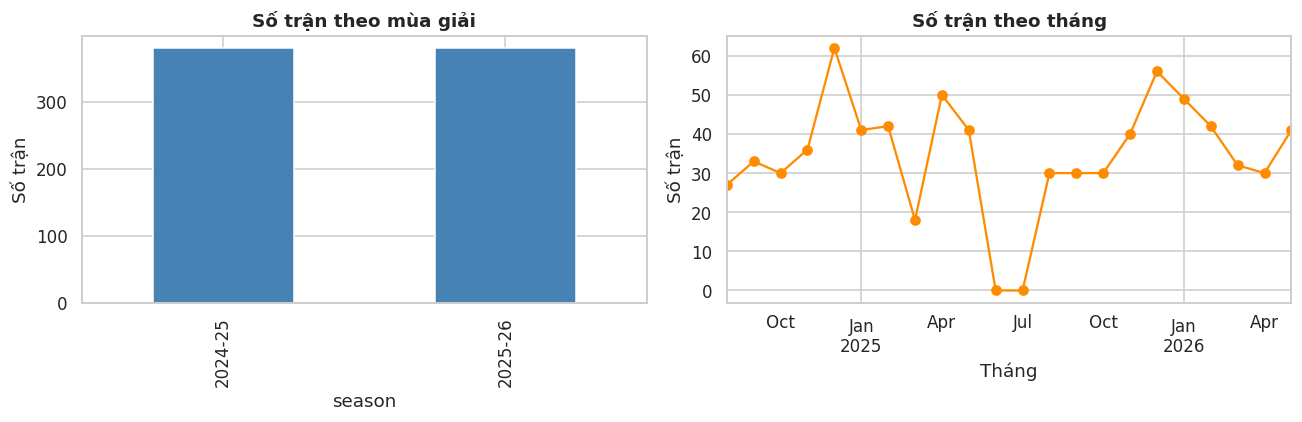

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

match_ml["season"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Số trận theo mùa giải")
axes[0].set_xlabel("season"); axes[0].set_ylabel("Số trận")

match_ml.set_index("match_date").resample("MS").size().plot(ax=axes[1], marker="o", color="darkorange")
axes[1].set_title("Số trận theo tháng")
axes[1].set_xlabel("Tháng"); axes[1].set_ylabel("Số trận")

plt.tight_layout()
plt.show()


### 3.1. Phân tích các biến mục tiêu (`target_*`)

Có 5 biến target khả dụng — ứng với 5 bài toán khác nhau có thể xây dựng từ cùng một bảng feature:

| Cột | Ý nghĩa | Loại bài toán |
|---|---|---|
| `target` | Kết quả H/D/A | Phân loại đa lớp (3 lớp) |
| `target_home_goals` / `target_away_goals` | Số bàn mỗi đội | Hồi quy / đếm (Poisson) |
| `target_total_goals` | Tổng bàn thắng | Hồi quy / đếm |
| `target_over25` | Trận có > 2.5 bàn hay không | Phân loại nhị phân |
| `target_btts` | Cả hai đội đều ghi bàn (Both Teams To Score) | Phân loại nhị phân |


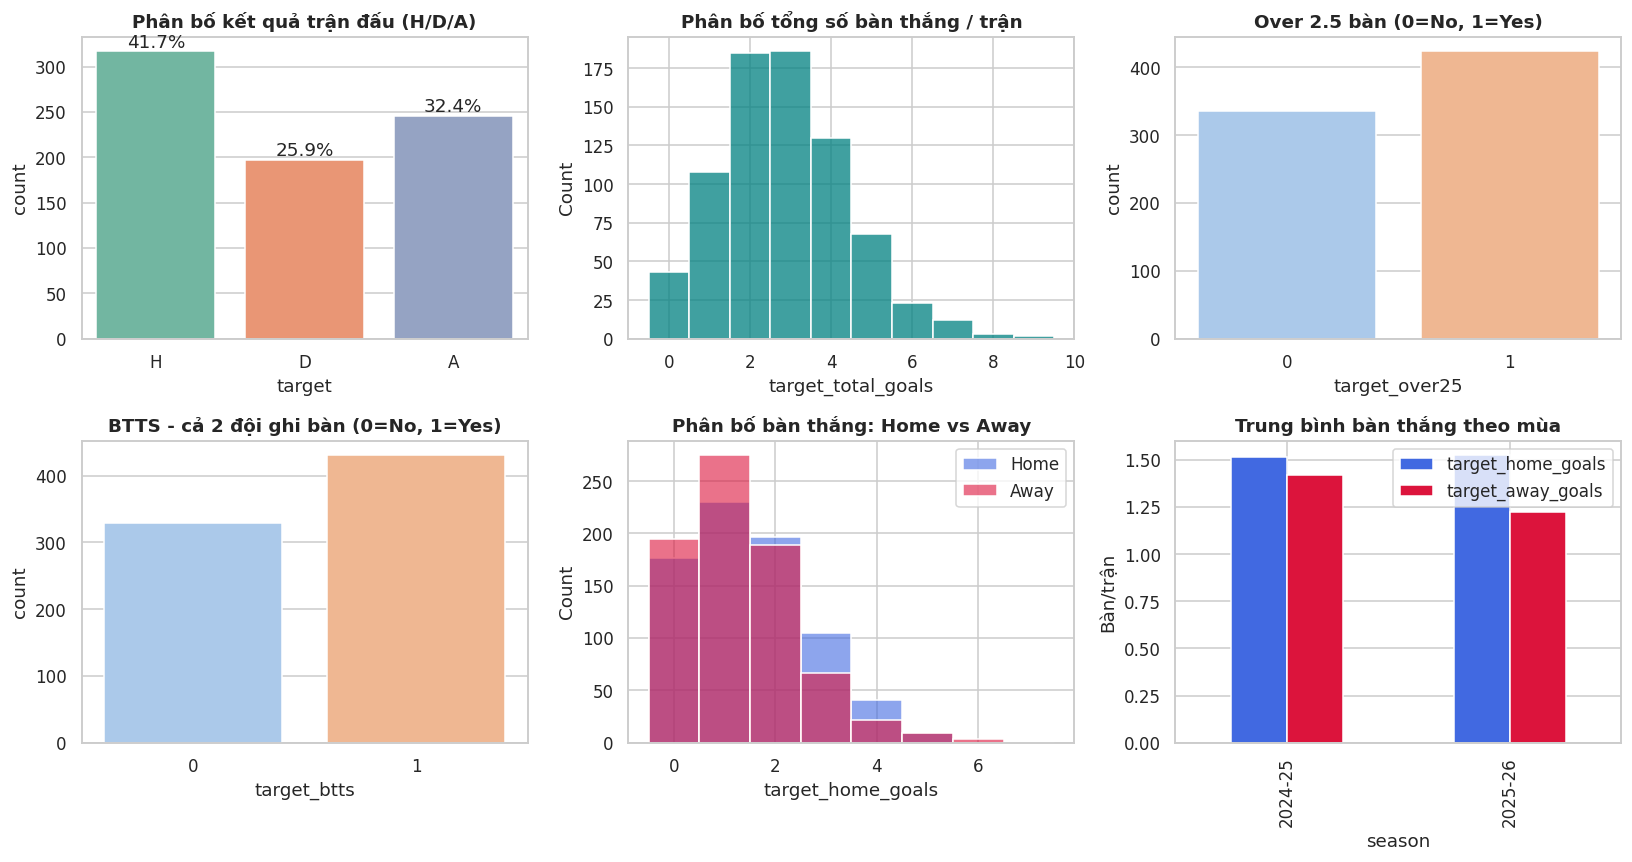

Tỷ lệ thắng sân nhà (home advantage): 41.7%
Tỷ lệ hòa: 25.9%
Tỷ lệ thắng sân khách: 32.4%
Trung bình tổng bàn/trận: 2.84


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# 1. Kết quả H/D/A
order = ["H", "D", "A"]
sns.countplot(x="target", data=match_ml, order=order, ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("Phân bố kết quả trận đấu (H/D/A)")
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{p.get_height()/len(match_ml):.1%}", (p.get_x()+p.get_width()/2, p.get_height()),
                          ha="center", va="bottom")

# 2. Tổng bàn thắng
sns.histplot(match_ml["target_total_goals"], bins=range(0, 10), discrete=True, ax=axes[0, 1], color="teal")
axes[0, 1].set_title("Phân bố tổng số bàn thắng / trận")

# 3. Over 2.5
sns.countplot(x="target_over25", data=match_ml, ax=axes[0, 2], palette="pastel")
axes[0, 2].set_title("Over 2.5 bàn (0=No, 1=Yes)")

# 4. BTTS
sns.countplot(x="target_btts", data=match_ml, ax=axes[1, 0], palette="pastel")
axes[1, 0].set_title("BTTS - cả 2 đội ghi bàn (0=No, 1=Yes)")

# 5. Bàn thắng đội nhà vs đội khách
sns.histplot(match_ml["target_home_goals"], bins=range(0,8), discrete=True, color="royalblue",
             label="Home", ax=axes[1, 1], alpha=0.6)
sns.histplot(match_ml["target_away_goals"], bins=range(0,8), discrete=True, color="crimson",
             label="Away", ax=axes[1, 1], alpha=0.6)
axes[1, 1].legend(); axes[1, 1].set_title("Phân bố bàn thắng: Home vs Away")

# 6. Trung bình bàn thắng theo mùa
avg_goals = match_ml.groupby("season")[["target_home_goals", "target_away_goals"]].mean()
avg_goals.plot(kind="bar", ax=axes[1, 2], color=["royalblue", "crimson"])
axes[1, 2].set_title("Trung bình bàn thắng theo mùa")
axes[1, 2].set_ylabel("Bàn/trận")

plt.tight_layout()
plt.show()

print("Tỷ lệ thắng sân nhà (home advantage):", f"{(match_ml['target']=='H').mean():.1%}")
print("Tỷ lệ hòa:", f"{(match_ml['target']=='D').mean():.1%}")
print("Tỷ lệ thắng sân khách:", f"{(match_ml['target']=='A').mean():.1%}")
print("Trung bình tổng bàn/trận:", round(match_ml["target_total_goals"].mean(), 2))


## 4. Phân tích Missing Values

Một số nhóm feature (đặc biệt là `l5`/`l10` phong độ, xG, thời tiết) sẽ **thiếu dữ liệu ở những trận đầu mùa**
vì chưa có đủ lịch sử — đây là điều **dự kiến** theo thiết kế chống leakage, không phải lỗi dữ liệu.

Số cột có missing: 84 / 126


,% missing
precip_mm,60.000000
temp_c,60.000000
wind_kmh,60.000000
is_raining,60.000000
pin_p_away,22.368421
pin_p_draw,22.368421
pin_p_home,22.368421
diff_pv_ratio_7_28,14.210526
away_pv_ratio_7_28,7.500000
away_pv_28d,7.500000


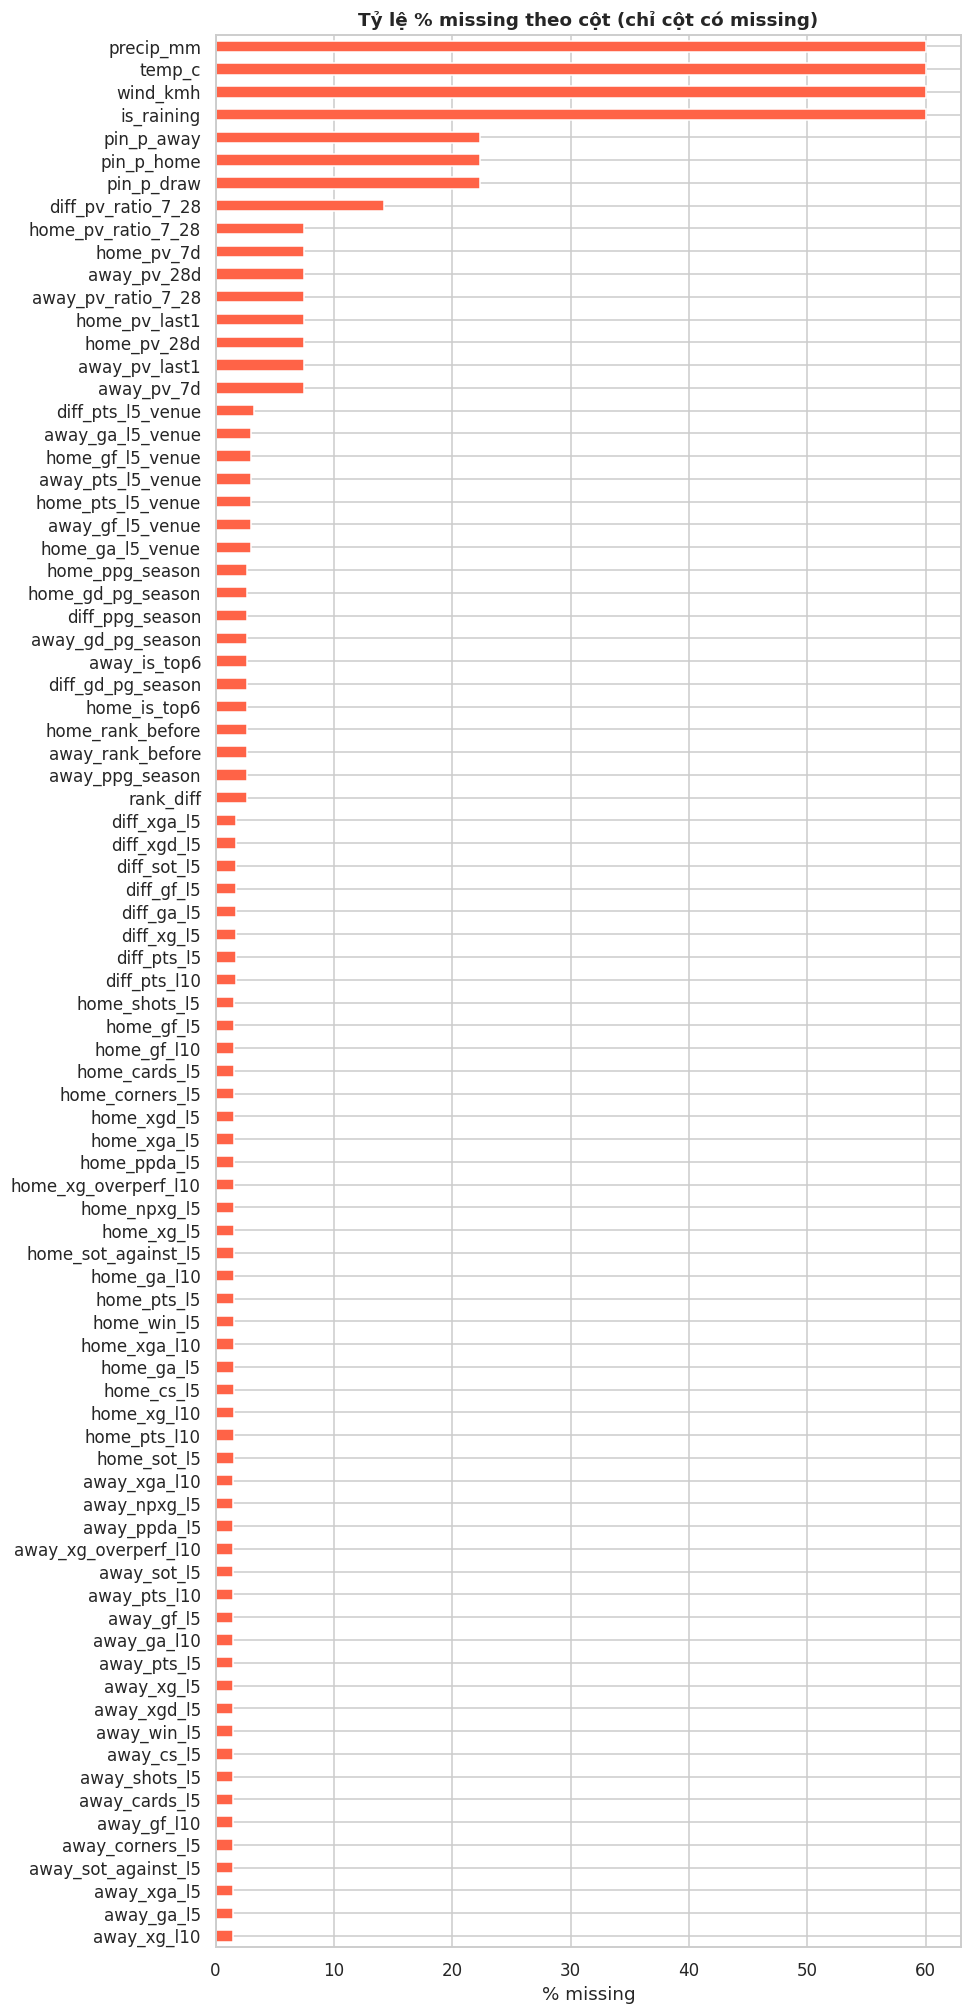

In [11]:
missing = (match_ml.isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0]

print(f"Số cột có missing: {len(missing)} / {match_ml.shape[1]}")
display(missing.to_frame("% missing").head(30))

fig, ax = plt.subplots(figsize=(9, max(4, len(missing) * 0.22)))
missing.sort_values().plot(kind="barh", ax=ax, color="tomato")
ax.set_title("Tỷ lệ % missing theo cột (chỉ cột có missing)")
ax.set_xlabel("% missing")
plt.tight_layout()
plt.show()


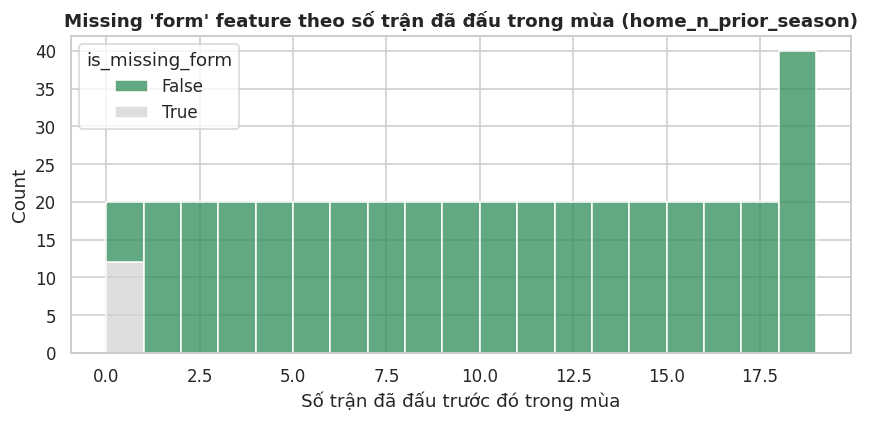

In [12]:
# Missing theo thời gian: các trận đầu mùa (n_prior thấp) missing nhiều hơn hẳn
form_cols = [c for c in match_ml.columns if c.startswith("home_pts_l5")]
tmp = match_ml[["home_n_prior_season"] + form_cols].copy()
tmp["is_missing_form"] = tmp[form_cols[0]].isna()

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=tmp, x="home_n_prior_season", hue="is_missing_form", multiple="stack",
             bins=range(0, 20), ax=ax, palette=["seagreen", "lightgray"])
ax.set_title("Missing 'form' feature theo số trận đã đấu trong mùa (home_n_prior_season)")
ax.set_xlabel("Số trận đã đấu trước đó trong mùa")
plt.tight_layout()
plt.show()


In [13]:
# Missing đặc biệt: thời tiết ~60% missing -> cần biết lý do trước khi dùng cho model
weather_cols = ["temp_c", "precip_mm", "wind_kmh", "is_raining"]
print("Missing % nhóm thời tiết:")
display(match_ml[weather_cols].isna().mean().mul(100).round(1))

# Missing có tương quan với mùa/thời điểm không?
print("\nMissing thời tiết theo mùa:")
display(match_ml.groupby("season")["temp_c"].apply(lambda s: s.isna().mean() * 100).round(1))


Missing % nhóm thời tiết:


,0
temp_c,60.0
precip_mm,60.0
wind_kmh,60.0
is_raining,60.0



Missing thời tiết theo mùa:


,temp_c
season,
2024-25,100.0
2025-26,20.0


## 5. EDA nhóm Elo

`feature_elo` cung cấp điểm Elo trước trận của 2 đội và xác suất kỳ vọng thắng sân nhà theo mô hình Elo.
Do dữ liệu bắt đầu từ mùa 2024-25, mọi đội đều khởi điểm **Elo = 1500** ở trận đầu tiên.

In [14]:
display(elo.describe())
print()
print("Số trận có elo_diff = 0 (cả 2 đội cùng điểm, thường là đầu mùa):",
      (elo["elo_diff"] == 0).sum(), "/", len(elo))


,elo_home,elo_away,elo_diff,elo_exp_home
count,760.000000,760.000000,760.000000,760.000000
mean,1511.243765,1510.239005,1.004761,0.587487
std,71.287689,71.566307,101.711688,0.130624
min,1280.189626,1286.432840,-368.709601,0.148263
25%,1476.510240,1473.876375,-58.133951,0.509880
50%,1511.515240,1511.230322,0.000000,0.592466
75%,1548.343952,1548.500570,62.083213,0.675145
max,1706.996704,1700.412180,370.050713,0.924446



Số trận có elo_diff = 0 (cả 2 đội cùng điểm, thường là đầu mùa): 10 / 760


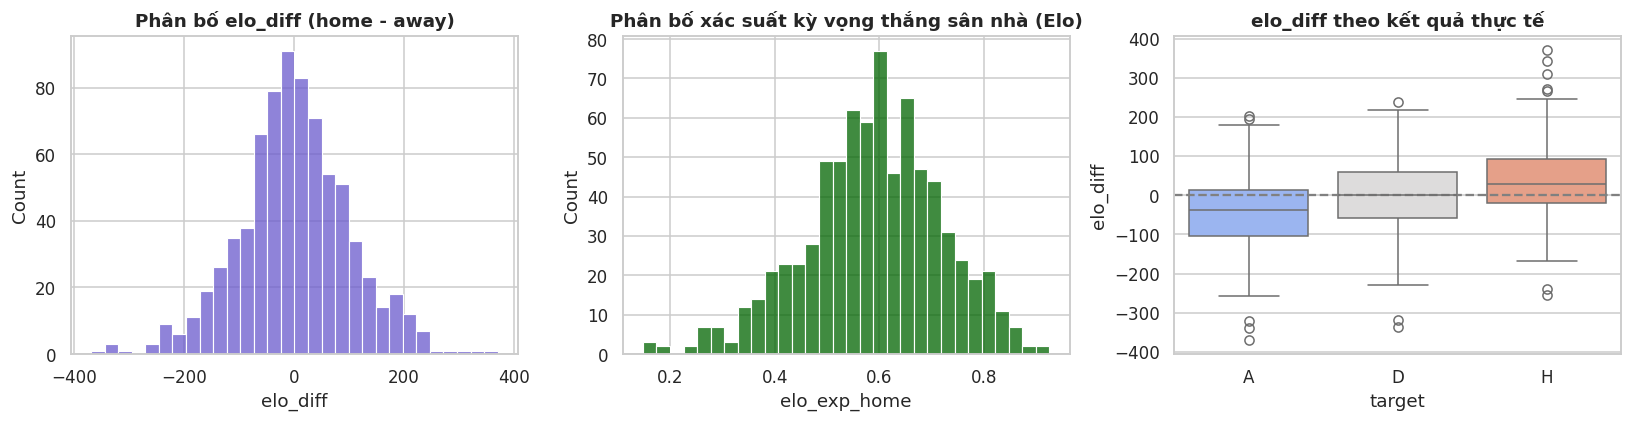

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(elo["elo_diff"], bins=30, ax=axes[0], color="slateblue")
axes[0].set_title("Phân bố elo_diff (home - away)")

sns.histplot(elo["elo_exp_home"], bins=30, ax=axes[1], color="darkgreen")
axes[1].set_title("Phân bố xác suất kỳ vọng thắng sân nhà (Elo)")

merged = match_ml.merge(elo[["match_id", "elo_diff", "elo_exp_home"]], on="match_id", suffixes=("", "_dup"))
sns.boxplot(x="target", y="elo_diff", data=merged, order=["A", "D", "H"], ax=axes[2], palette="coolwarm")
axes[2].set_title("elo_diff theo kết quả thực tế")
axes[2].axhline(0, color="gray", linestyle="--")

plt.tight_layout()
plt.show()


**Kiểm tra hiệu chỉnh (calibration) của Elo:** chia `elo_exp_home` thành các bin xác suất và so sánh
với tỷ lệ thắng sân nhà thực tế trong từng bin — mô hình Elo tốt thì 2 đường phải gần trùng nhau.

,n,xac_suat_du_bao,ty_le_thang_thuc_te
elo_bin,,,
"(0.147, 0.488]",152,0.396254,0.177632
"(0.488, 0.56]",152,0.527058,0.335526
"(0.56, 0.621]",152,0.592953,0.460526
"(0.621, 0.697]",152,0.658300,0.526316
"(0.697, 0.924]",152,0.762873,0.585526


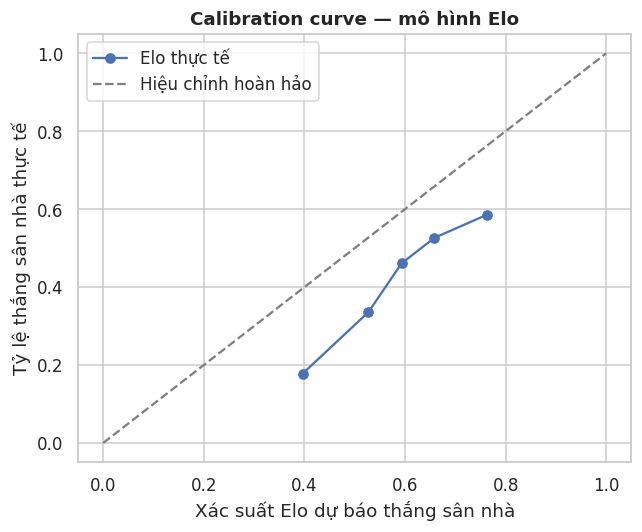

In [16]:
merged["elo_bin"] = pd.qcut(merged["elo_exp_home"], q=5, duplicates="drop")
calib_elo = merged.groupby("elo_bin").agg(
    n=("target", "size"),
    xac_suat_du_bao=("elo_exp_home", "mean"),
    ty_le_thang_thuc_te=("target", lambda s: (s == "H").mean()),
)
display(calib_elo)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(calib_elo["xac_suat_du_bao"], calib_elo["ty_le_thang_thuc_te"], "o-", label="Elo thực tế")
ax.plot([0, 1], [0, 1], "--", color="gray", label="Hiệu chỉnh hoàn hảo")
ax.set_xlabel("Xác suất Elo dự báo thắng sân nhà")
ax.set_ylabel("Tỷ lệ thắng sân nhà thực tế")
ax.set_title("Calibration curve — mô hình Elo")
ax.legend()
plt.tight_layout()
plt.show()


## 6. EDA nhóm Market Odds (thị trường cược)

`feature_market` chứa xác suất ngầm định (đã bỏ margin) từ trung bình nhiều nhà cái (`mkt_*`) và
riêng từ Pinnacle (`pin_*`) — nhà cái thường được xem là "sharp" (hiệu chỉnh tốt) trong giới phân tích cược.

In [17]:
display(market.describe())


,mkt_p_home,mkt_p_draw,mkt_p_away,mkt_margin,mkt_n_books,pin_p_home,pin_p_draw,pin_p_away
count,760.000000,760.000000,760.000000,760.000000,760.000000,590.000000,590.000000,590.000000
mean,0.442272,0.237557,0.320171,0.050199,2.971053,0.444435,0.235513,0.320052
std,0.179966,0.042531,0.162736,0.004751,0.811124,0.186976,0.046063,0.168233
min,0.059310,0.075602,0.039623,0.039611,2.000000,0.068472,0.069593,0.037381
25%,0.302569,0.217215,0.190744,0.047077,2.000000,0.297595,0.210592,0.184353
50%,0.430958,0.248407,0.292599,0.049265,3.000000,0.426481,0.246894,0.296984
75%,0.579195,0.268136,0.426861,0.052721,4.000000,0.585615,0.269654,0.428097
max,0.884775,0.312377,0.831358,0.086207,4.000000,0.891819,0.315197,0.806130


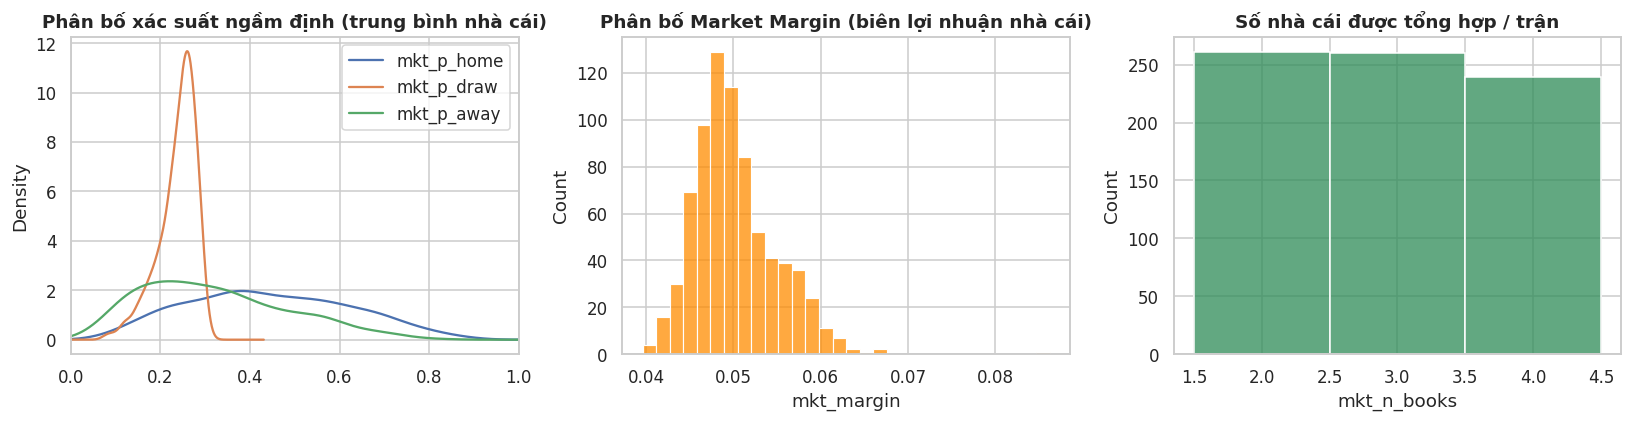

Market margin trung bình: 5.02 %


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

market[["mkt_p_home", "mkt_p_draw", "mkt_p_away"]].plot(kind="kde", ax=axes[0])
axes[0].set_title("Phân bố xác suất ngầm định (trung bình nhà cái)")
axes[0].set_xlim(0, 1)

sns.histplot(market["mkt_margin"], bins=30, ax=axes[1], color="darkorange")
axes[1].set_title("Phân bố Market Margin (biên lợi nhuận nhà cái)")

sns.histplot(market["mkt_n_books"], bins=range(0, int(market['mkt_n_books'].max())+2),
             discrete=True, ax=axes[2], color="seagreen")
axes[2].set_title("Số nhà cái được tổng hợp / trận")

plt.tight_layout()
plt.show()

print("Market margin trung bình:", round(market["mkt_margin"].mean() * 100, 2), "%")


**So sánh xác suất trung bình nhiều nhà cái (`mkt_p_home`) với riêng Pinnacle (`pin_p_home`)** —
nếu 2 giá trị gần nhau, chứng tỏ thị trường khá đồng thuận.

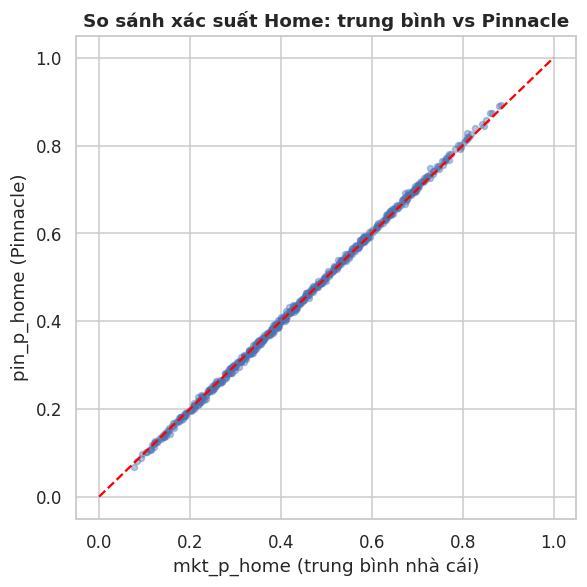

Hệ số tương quan mkt_p_home vs pin_p_home: 0.9997


In [19]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(market["mkt_p_home"], market["pin_p_home"], alpha=0.4, s=15)
ax.plot([0, 1], [0, 1], "--", color="red")
ax.set_xlabel("mkt_p_home (trung bình nhà cái)")
ax.set_ylabel("pin_p_home (Pinnacle)")
ax.set_title("So sánh xác suất Home: trung bình vs Pinnacle")
plt.tight_layout()
plt.show()

corr = market["mkt_p_home"].corr(market["pin_p_home"])
print("Hệ số tương quan mkt_p_home vs pin_p_home:", round(corr, 4))


**Calibration của thị trường (đáng tin cậy hơn Elo do phản ánh nhiều thông tin, ví dụ đội hình, phong độ):**

,n,xac_suat_du_bao,ty_le_thang_thuc_te
mkt_bin,,,
"(0.0583, 0.271]",152,0.197276,0.151316
"(0.271, 0.381]",152,0.331403,0.322368
"(0.381, 0.488]",152,0.431904,0.427632
"(0.488, 0.609]",152,0.547541,0.513158
"(0.609, 0.885]",152,0.703237,0.671053


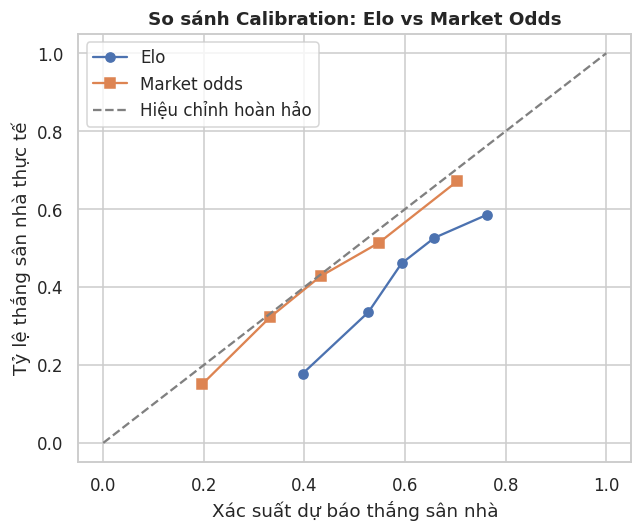

In [20]:
m2 = match_ml.dropna(subset=["mkt_p_home"]).copy()
m2["mkt_bin"] = pd.qcut(m2["mkt_p_home"], q=5, duplicates="drop")
calib_mkt = m2.groupby("mkt_bin").agg(
    n=("target", "size"),
    xac_suat_du_bao=("mkt_p_home", "mean"),
    ty_le_thang_thuc_te=("target", lambda s: (s == "H").mean()),
)
display(calib_mkt)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(calib_elo["xac_suat_du_bao"], calib_elo["ty_le_thang_thuc_te"], "o-", label="Elo")
ax.plot(calib_mkt["xac_suat_du_bao"], calib_mkt["ty_le_thang_thuc_te"], "s-", label="Market odds")
ax.plot([0, 1], [0, 1], "--", color="gray", label="Hiệu chỉnh hoàn hảo")
ax.set_xlabel("Xác suất dự báo thắng sân nhà")
ax.set_ylabel("Tỷ lệ thắng sân nhà thực tế")
ax.set_title("So sánh Calibration: Elo vs Market Odds")
ax.legend()
plt.tight_layout()
plt.show()


## 7. EDA nhóm xG (Expected Goals)

`feature_team_xg` ở Grain **1 dòng / đội / trận**, còn `feature_match_ml` đã pivot thành `home_xg_l5`,
`away_xg_l5`... Ta xem cả 2 góc nhìn.

In [21]:
display(team_xg.describe())
print("\n% missing theo cột:")
display(team_xg.isna().mean().mul(100).round(1))


,xg_l5,xga_l5,npxg_l5,xgd_l5,ppda_l5,xg_l10,xga_l10,xg_overperf_l10
count,1497.000000,1497.000000,1497.000000,1497.000000,1497.000000,1497.000000,1497.000000,1497.000000
mean,1.565222,1.559435,1.476766,0.005788,12.448182,1.568290,1.557494,-0.146484
std,0.503017,0.498925,0.473880,0.839709,3.206166,0.438772,0.431090,0.344600
min,0.342601,0.342601,0.342601,-3.586459,3.789474,0.342601,0.342601,-1.954830
25%,1.189907,1.213843,1.134060,-0.518833,10.108849,1.231832,1.289104,-0.348622
50%,1.524932,1.511252,1.421318,0.016657,11.879949,1.552871,1.511384,-0.148723
75%,1.890570,1.868730,1.779055,0.574908,14.352071,1.879188,1.787686,0.057218
max,3.929060,3.929060,3.929060,3.586459,29.086124,3.929060,3.929060,2.275632



% missing theo cột:


,0
match_id,0.0
team_key,0.0
xg_l5,1.5
xga_l5,1.5
npxg_l5,1.5
xgd_l5,1.5
ppda_l5,1.5
xg_l10,1.5
xga_l10,1.5
xg_overperf_l10,1.5


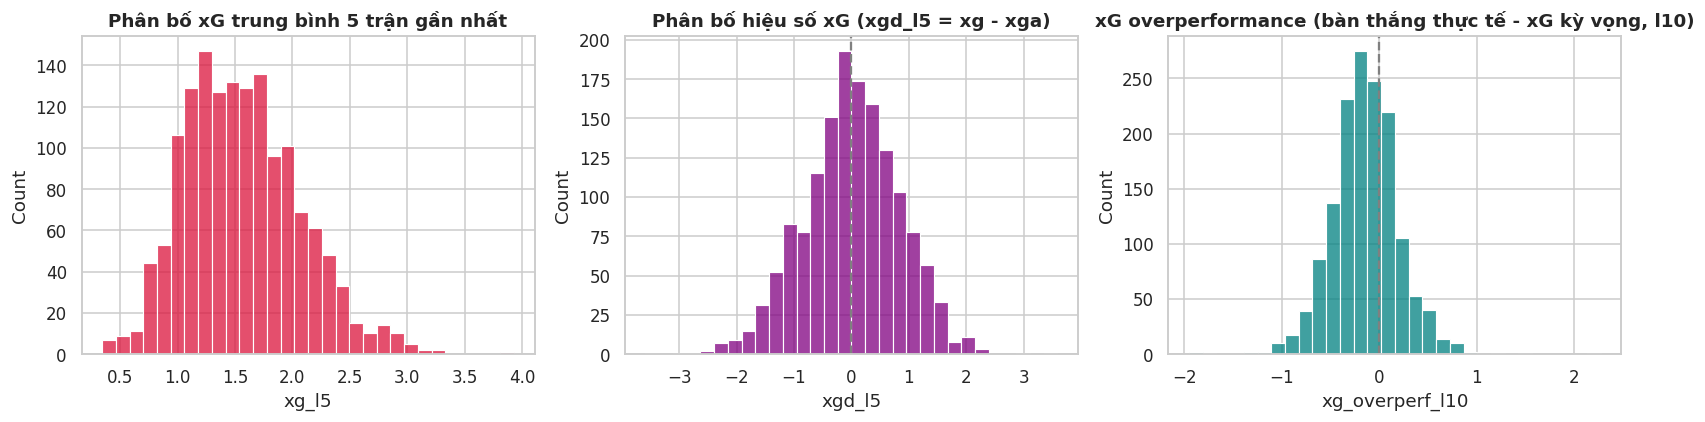

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(team_xg["xg_l5"].dropna(), bins=30, ax=axes[0], color="crimson")
axes[0].set_title("Phân bố xG trung bình 5 trận gần nhất")

sns.histplot(team_xg["xgd_l5"].dropna(), bins=30, ax=axes[1], color="purple")
axes[1].axvline(0, color="gray", linestyle="--")
axes[1].set_title("Phân bố hiệu số xG (xgd_l5 = xg - xga)")

sns.histplot(team_xg["xg_overperf_l10"].dropna(), bins=30, ax=axes[2], color="teal")
axes[2].axvline(0, color="gray", linestyle="--")
axes[2].set_title("xG overperformance (bàn thắng thực tế - xG kỳ vọng, l10)")

plt.tight_layout()
plt.show()


**xG có thực sự dự báo được bàn thắng trận tiếp theo không?** — So sánh `home_xg_l5` (xG trung bình
5 trận trước) với `target_home_goals` (bàn thắng thực tế trận hiện tại).

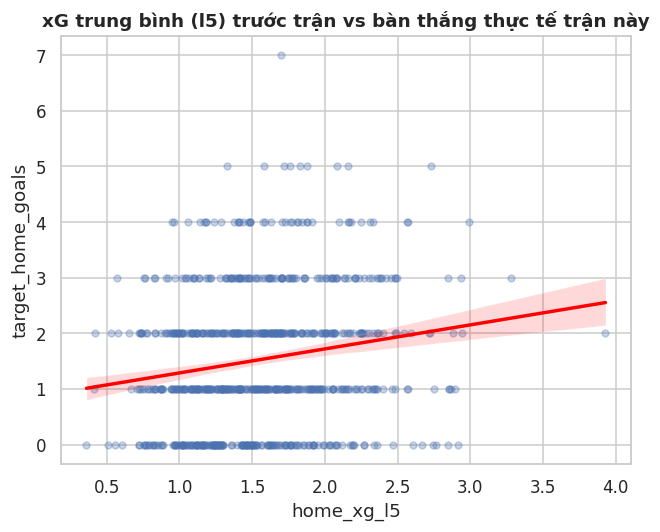

Pearson r = 0.177  (p-value = 0.0000)


In [23]:
fig, ax = plt.subplots(figsize=(6, 5))
sub = match_ml.dropna(subset=["home_xg_l5"])
sns.regplot(x="home_xg_l5", y="target_home_goals", data=sub, ax=ax,
            scatter_kws={"alpha": 0.3, "s": 20}, line_kws={"color": "red"})
ax.set_title("xG trung bình (l5) trước trận vs bàn thắng thực tế trận này")
plt.tight_layout()
plt.show()

corr, pval = stats.pearsonr(sub["home_xg_l5"], sub["target_home_goals"])
print(f"Pearson r = {corr:.3f}  (p-value = {pval:.4f})")


## 8. EDA nhóm Form (phong độ đội)

`feature_team_match` ở Grain **1 dòng / đội / trận**, chứa các chỉ số phong độ 5/10 trận gần nhất.

In [24]:
display(team_match[["pts_l5", "gf_l5", "ga_l5", "sot_l5", "shots_l5", "corners_l5",
                     "cards_l5", "win_l5", "cs_l5", "ppg_season"]].describe())


,pts_l5,gf_l5,ga_l5,sot_l5,shots_l5,corners_l5,cards_l5,win_l5,cs_l5,ppg_season
count,1497.000000,1497.000000,1497.000000,1497.000000,1497.000000,1497.000000,1497.000000,1497.000000,1497.000000,1480.000000
mean,1.378490,1.420641,1.415854,4.367680,12.711601,5.088321,2.071944,0.374683,0.248686,1.373212
std,0.706351,0.604809,0.605543,1.233374,2.917110,1.620389,0.728206,0.251828,0.209372,0.581257
min,0.000000,0.000000,0.000000,1.000000,3.000000,0.800000,0.000000,0.000000,0.000000,0.000000
25%,0.800000,1.000000,1.000000,3.500000,10.600000,4.000000,1.600000,0.200000,0.000000,1.027027
50%,1.400000,1.400000,1.400000,4.200000,12.600000,5.000000,2.000000,0.400000,0.200000,1.406829
75%,1.800000,1.800000,1.800000,5.200000,14.600000,6.000000,2.600000,0.600000,0.400000,1.708333
max,3.000000,3.800000,4.000000,9.000000,24.000000,13.000000,5.000000,1.000000,1.000000,3.000000


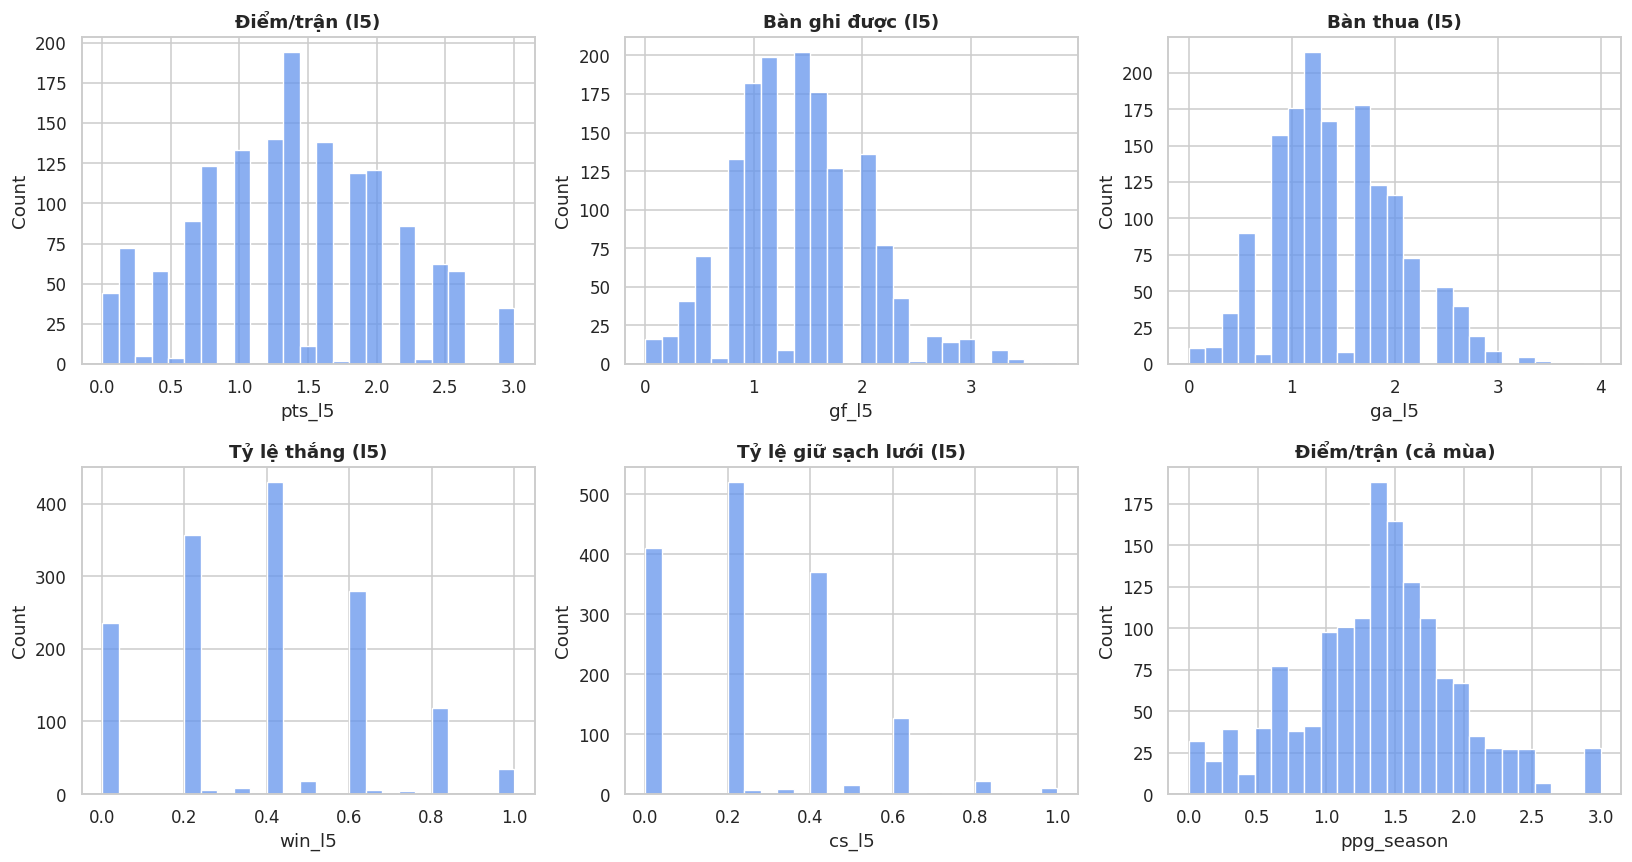

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
form_plot_cols = ["pts_l5", "gf_l5", "ga_l5", "win_l5", "cs_l5", "ppg_season"]
titles = ["Điểm/trận (l5)", "Bàn ghi được (l5)", "Bàn thua (l5)",
          "Tỷ lệ thắng (l5)", "Tỷ lệ giữ sạch lưới (l5)", "Điểm/trận (cả mùa)"]

for ax, col, title in zip(axes.flat, form_plot_cols, titles):
    sns.histplot(team_match[col].dropna(), bins=25, ax=ax, color="cornflowerblue")
    ax.set_title(title)

plt.tight_layout()
plt.show()


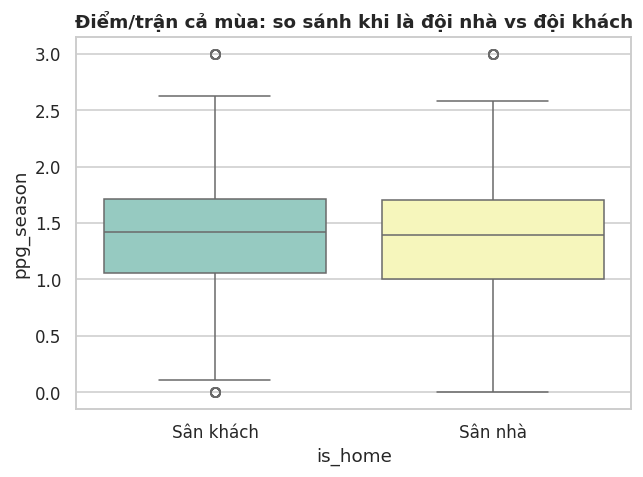

In [26]:
# Home vs Away: phong độ có khác nhau theo sân thi đấu?
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.boxplot(x="is_home", y="ppg_season", data=team_match, ax=ax, palette="Set3")
ax.set_xticklabels(["Sân khách", "Sân nhà"])
ax.set_title("Điểm/trận cả mùa: so sánh khi là đội nhà vs đội khách")
plt.tight_layout()
plt.show()


**Tương quan giữa `diff_*` (chênh lệch phong độ home - away) và kết quả trận đấu:**

Các cột diff_*: ['diff_pts_l5', 'diff_gf_l5', 'diff_ga_l5', 'diff_sot_l5', 'diff_pts_l10', 'diff_ppg_season', 'diff_gd_pg_season', 'diff_pts_l5_venue', 'diff_xg_l5', 'diff_xga_l5', 'diff_xgd_l5', 'diff_pv_ratio_7_28']


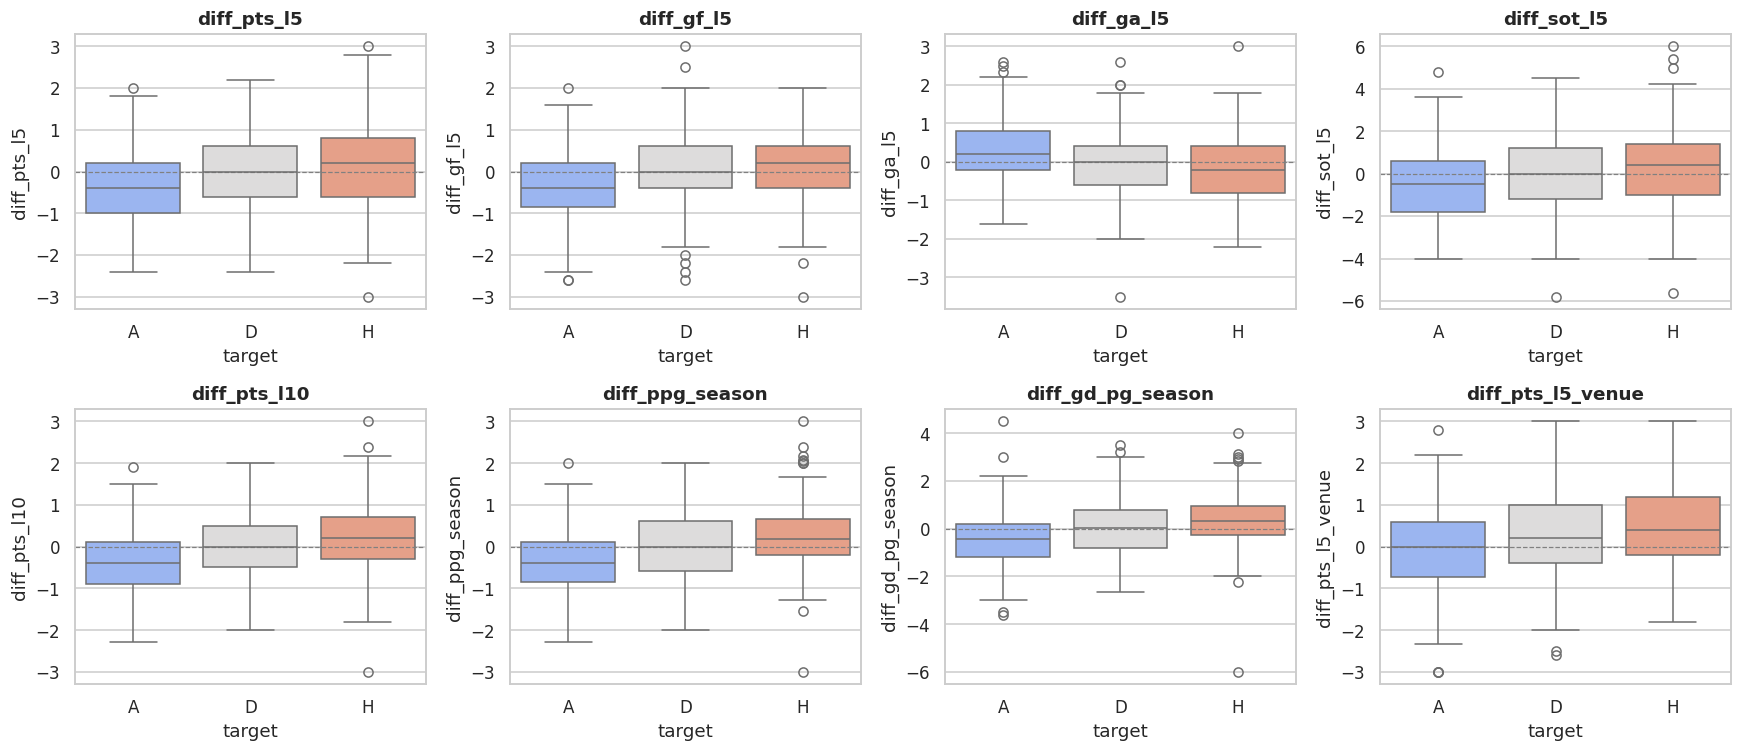

In [27]:
diff_cols = [c for c in match_ml.columns if c.startswith("diff_")]
print("Các cột diff_*:", diff_cols)

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, diff_cols[:8]):
    sns.boxplot(x="target", y=col, data=match_ml, order=["A", "D", "H"], ax=ax, palette="coolwarm")
    ax.set_title(col)
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()


## 9. EDA nhóm Position (vị trí bảng xếp hạng trước trận)

`feature_league_position` cho biết điểm số, hiệu số, thứ hạng của mỗi đội **trước khi** trận đấu diễn ra.

In [28]:
display(league_pos.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
match_id,1520,760,E0_2025-26_20260517_Newcastle_WestHam,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
team_key,1520,23,Arsenal,76,NaN,NaN,NaN,NaN,NaN,NaN,NaN
played_before,1520.0,NaN,NaN,NaN,18.5,10.969465,0.0,9.0,18.5,28.0,37.0
points_before,1520.0,NaN,NaN,NaN,25.376316,18.075891,0.0,10.0,23.0,38.0,83.0
gd_before,1520.0,NaN,NaN,NaN,0.009211,14.329837,-59.0,-5.0,0.0,6.0,48.0
rank_before,1480.0,<NA>,<NA>,<NA>,10.741892,5.693157,1.0,6.0,11.0,16.0,20.0
is_top6,1480.0,<NA>,<NA>,<NA>,0.279054,0.448686,0.0,0.0,0.0,1.0,1.0


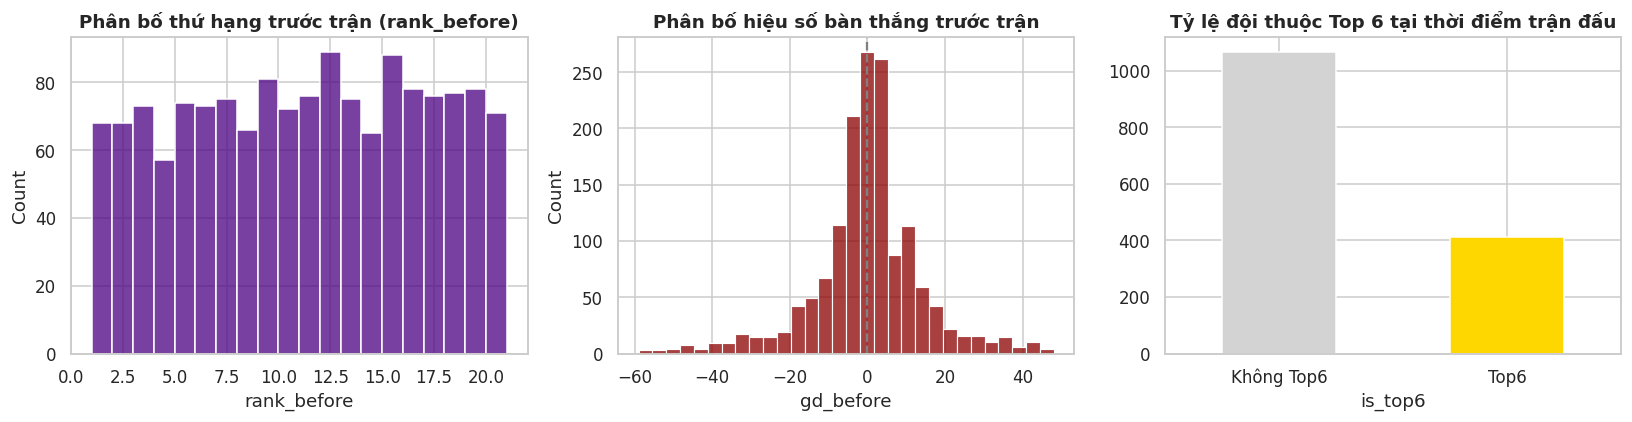

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(league_pos["rank_before"].dropna().astype(int), bins=range(1, 22), ax=axes[0], color="indigo")
axes[0].set_title("Phân bố thứ hạng trước trận (rank_before)")

sns.histplot(league_pos["gd_before"].dropna(), bins=30, ax=axes[1], color="darkred")
axes[1].axvline(0, color="gray", linestyle="--")
axes[1].set_title("Phân bố hiệu số bàn thắng trước trận")

league_pos["is_top6"].value_counts().plot(kind="bar", ax=axes[2], color=["lightgray", "gold"])
axes[2].set_title("Tỷ lệ đội thuộc Top 6 tại thời điểm trận đấu")
axes[2].set_xticklabels(["Không Top6", "Top6"], rotation=0)

plt.tight_layout()
plt.show()


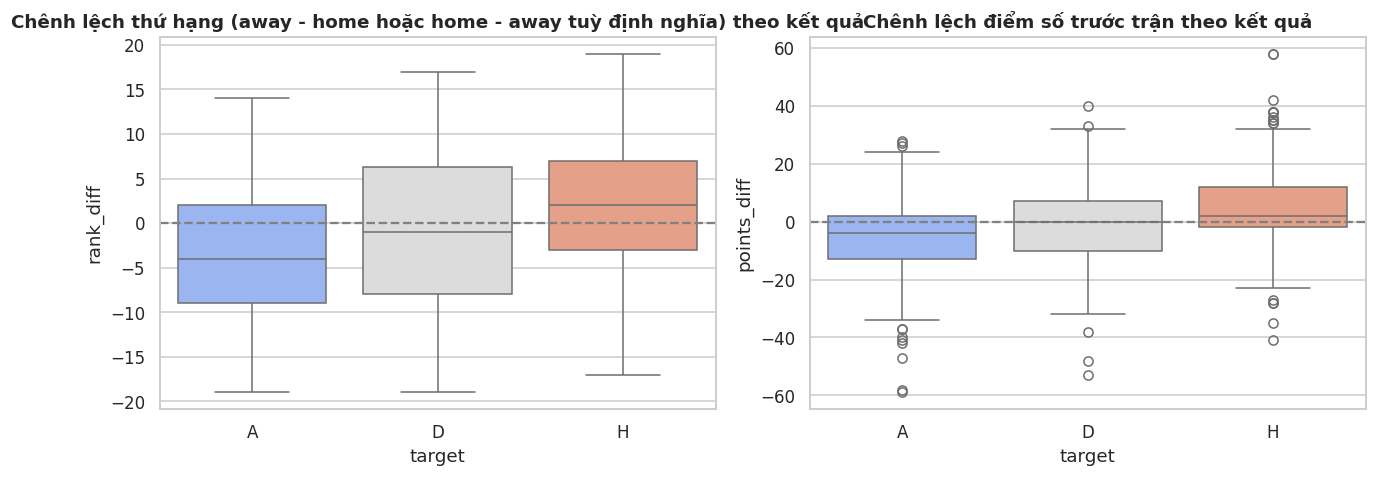

In [30]:
# rank_diff và points_diff có tách biệt tốt các kết quả trận đấu không?
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(x="target", y="rank_diff", data=match_ml, order=["A", "D", "H"], ax=axes[0], palette="coolwarm")
axes[0].set_title("Chênh lệch thứ hạng (away - home hoặc home - away tuỳ định nghĩa) theo kết quả")
axes[0].axhline(0, color="gray", linestyle="--")

sns.boxplot(x="target", y="points_diff", data=match_ml, order=["A", "D", "H"], ax=axes[1], palette="coolwarm")
axes[1].set_title("Chênh lệch điểm số trước trận theo kết quả")
axes[1].axhline(0, color="gray", linestyle="--")

plt.tight_layout()
plt.show()


## 10. EDA nhóm Context (thời gian thi đấu & thời tiết)

In [31]:
display(match_ctx.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
match_id,760,760,E0_2025-26_20260524_WestHam_Leeds,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kickoff_hour,760.0,NaN,NaN,NaN,16.053947,2.348657,12.0,15.0,15.0,17.0,20.0
dow,760.0,NaN,NaN,NaN,3.407895,2.676584,0.0,0.0,4.0,6.0,6.0
month,760.0,NaN,NaN,NaN,6.596053,3.989279,1.0,3.0,5.0,11.0,12.0
is_weekend,760.0,NaN,NaN,NaN,0.768421,0.422119,0.0,1.0,1.0,1.0,1.0
temp_c,304.0,NaN,NaN,NaN,12.064309,5.340752,-0.775,8.35,11.8,14.575,31.9
precip_mm,304.0,NaN,NaN,NaN,0.143503,0.390176,0.0,0.0,0.0,0.1,3.85
wind_kmh,304.0,NaN,NaN,NaN,14.706086,6.853842,1.85,10.29375,13.9125,18.35625,41.375
is_raining,304.0,<NA>,<NA>,<NA>,0.266447,0.44283,0.0,0.0,0.0,1.0,1.0


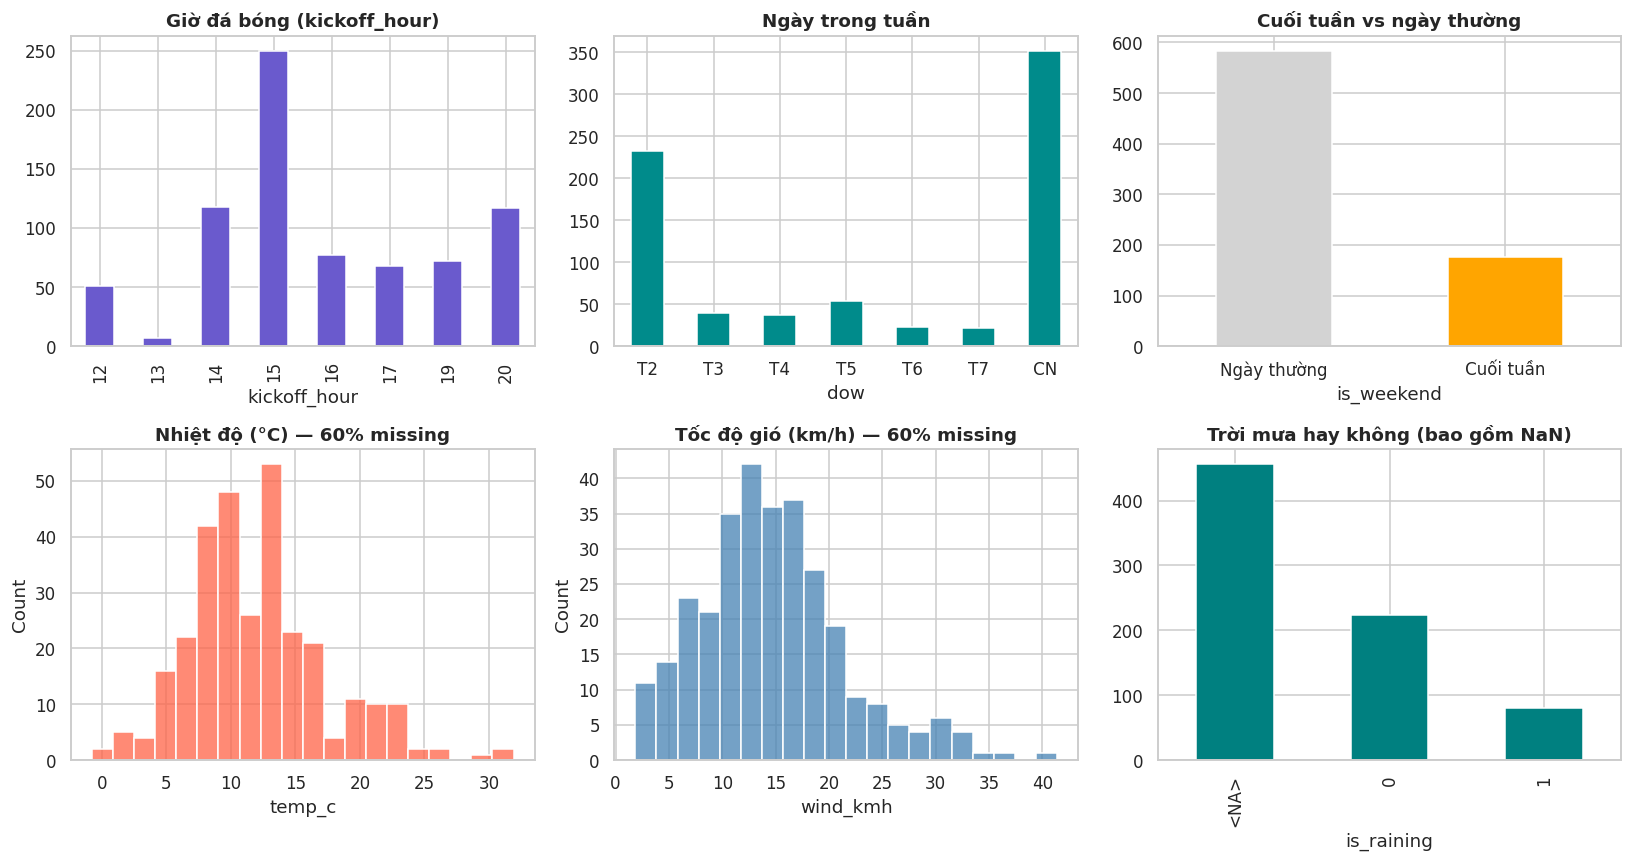

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

match_ctx["kickoff_hour"].value_counts().sort_index().plot(kind="bar", ax=axes[0, 0], color="slateblue")
axes[0, 0].set_title("Giờ đá bóng (kickoff_hour)")

dow_labels = ["T2", "T3", "T4", "T5", "T6", "T7", "CN"]
match_ctx["dow"].value_counts().sort_index().plot(kind="bar", ax=axes[0, 1], color="darkcyan")
axes[0, 1].set_xticklabels(dow_labels, rotation=0)
axes[0, 1].set_title("Ngày trong tuần")

match_ctx["is_weekend"].value_counts().plot(kind="bar", ax=axes[0, 2], color=["lightgray", "orange"])
axes[0, 2].set_title("Cuối tuần vs ngày thường")
axes[0, 2].set_xticklabels(["Ngày thường", "Cuối tuần"], rotation=0)

sns.histplot(match_ctx["temp_c"].dropna(), bins=20, ax=axes[1, 0], color="tomato")
axes[1, 0].set_title(f"Nhiệt độ (°C) — {match_ctx['temp_c'].isna().mean():.0%} missing")

sns.histplot(match_ctx["wind_kmh"].dropna(), bins=20, ax=axes[1, 1], color="steelblue")
axes[1, 1].set_title(f"Tốc độ gió (km/h) — {match_ctx['wind_kmh'].isna().mean():.0%} missing")

match_ctx["is_raining"].value_counts(dropna=False).plot(kind="bar", ax=axes[1, 2], color="teal")
axes[1, 2].set_title("Trời mưa hay không (bao gồm NaN)")

plt.tight_layout()
plt.show()


**Thời tiết có ảnh hưởng đến tổng số bàn thắng không?** (chỉ xét các trận có dữ liệu thời tiết)

Số trận có dữ liệu thời tiết: 304 / 760


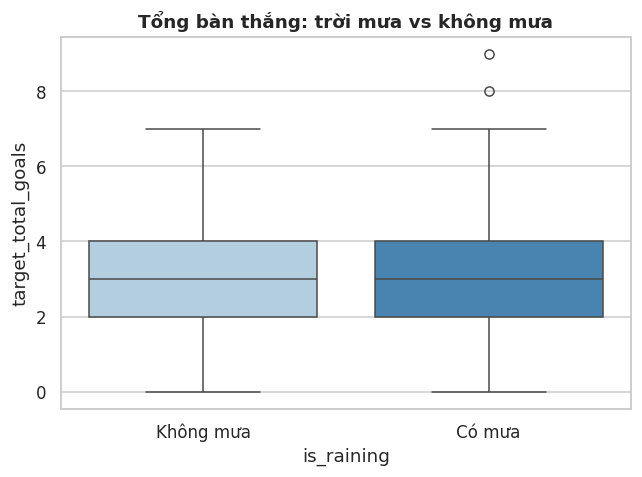

                mean       std  count
is_raining                           
0           2.695067  1.520527    223
1           2.987654  1.706560     81


In [33]:
w = match_ml.dropna(subset=["is_raining"])
print("Số trận có dữ liệu thời tiết:", len(w), "/", len(match_ml))

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.boxplot(x="is_raining", y="target_total_goals", data=w, ax=ax, palette="Blues")
ax.set_xticklabels(["Không mưa", "Có mưa"])
ax.set_title("Tổng bàn thắng: trời mưa vs không mưa")
plt.tight_layout()
plt.show()

print(w.groupby("is_raining")["target_total_goals"].agg(["mean", "std", "count"]))


## 11. EDA nhóm Attention (lượt xem Wikipedia)

`feature_team_attention` đo mức độ "được chú ý" của một đội qua lượt xem trang Wikipedia
(`pv_7d`, `pv_28d`) — có thể dùng như proxy cho sự kiện bất thường (chuyển nhượng, khủng hoảng,
kỳ vọng truyền thông...) trước trận.

In [34]:
display(team_att.describe())


,pv_7d,pv_28d,pv_last1,pv_ratio_7_28
count,1406.000000,1406.000000,1406.000000,1406.000000
mean,5855.128632,5796.460145,4913.165007,1.004560
std,4775.660867,3810.320857,4018.458597,0.284756
min,1100.428571,1446.607143,1073.000000,0.301791
25%,2761.964286,3010.508929,2361.750000,0.821396
50%,4162.428571,4355.339286,3353.500000,0.971194
75%,7877.392857,7861.598214,6691.750000,1.157512
max,59175.285714,25308.821429,51206.000000,2.980642


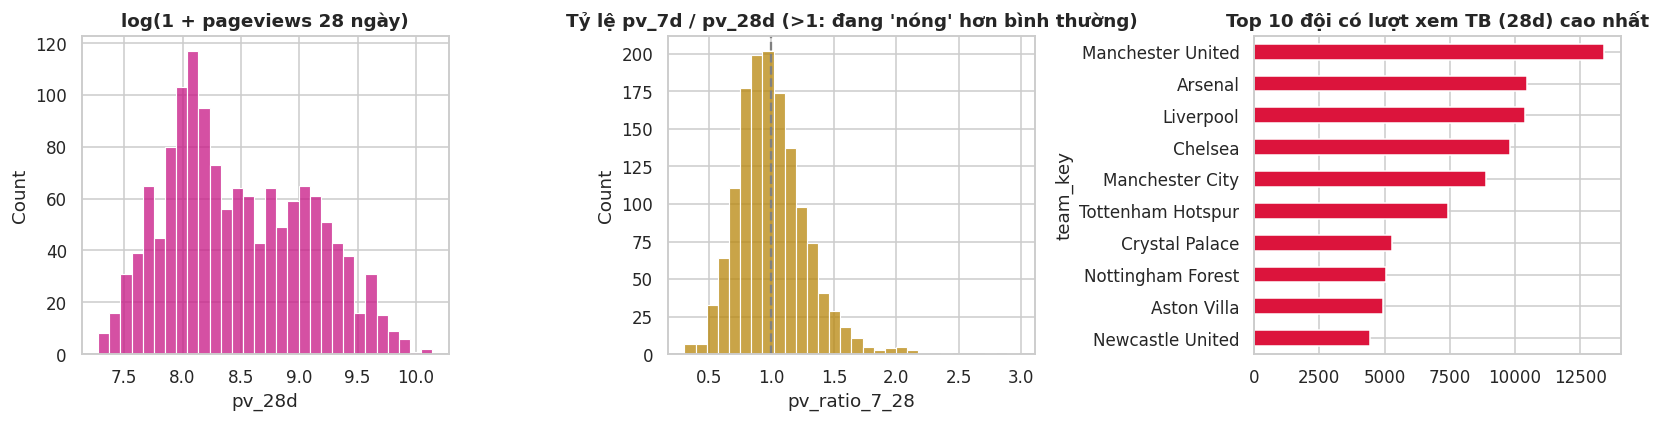

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(np.log1p(team_att["pv_28d"].dropna()), bins=30, ax=axes[0], color="mediumvioletred")
axes[0].set_title("log(1 + pageviews 28 ngày)")

sns.histplot(team_att["pv_ratio_7_28"].dropna(), bins=30, ax=axes[1], color="darkgoldenrod")
axes[1].axvline(1, color="gray", linestyle="--")
axes[1].set_title("Tỷ lệ pv_7d / pv_28d (>1: đang 'nóng' hơn bình thường)")

# Top 10 đội được chú ý nhiều nhất trung bình
top_att = team_att.groupby("team_key")["pv_28d"].mean().sort_values(ascending=False).head(10)
top_att.plot(kind="barh", ax=axes[2], color="crimson")
axes[2].invert_yaxis()
axes[2].set_title("Top 10 đội có lượt xem TB (28d) cao nhất")

plt.tight_layout()
plt.show()


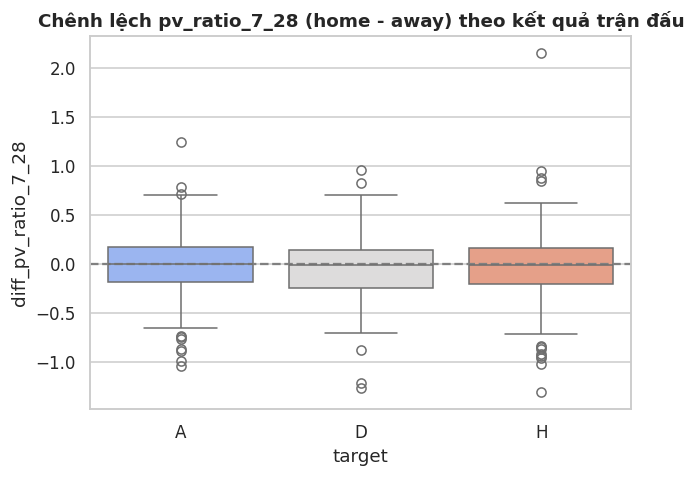

In [36]:
# pv_ratio cao (đội đang được chú ý bất thường) có liên quan đến việc thắng/thua không?
sub = match_ml.dropna(subset=["diff_pv_ratio_7_28"])
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.boxplot(x="target", y="diff_pv_ratio_7_28", data=sub, order=["A", "D", "H"], ax=ax, palette="coolwarm")
ax.axhline(0, color="gray", linestyle="--")
ax.set_title("Chênh lệch pv_ratio_7_28 (home - away) theo kết quả trận đấu")
plt.tight_layout()
plt.show()


## 12. Ma trận tương quan tổng thể & đa cộng tuyến

Gộp các feature số quan trọng nhất (đại diện mỗi nhóm) để xem tương quan qua lại — vừa để hiểu dữ liệu,
vừa để phát hiện **đa cộng tuyến** (các cặp feature gần như đo cùng một thứ) trước khi đưa vào model
tuyến tính/logistic.

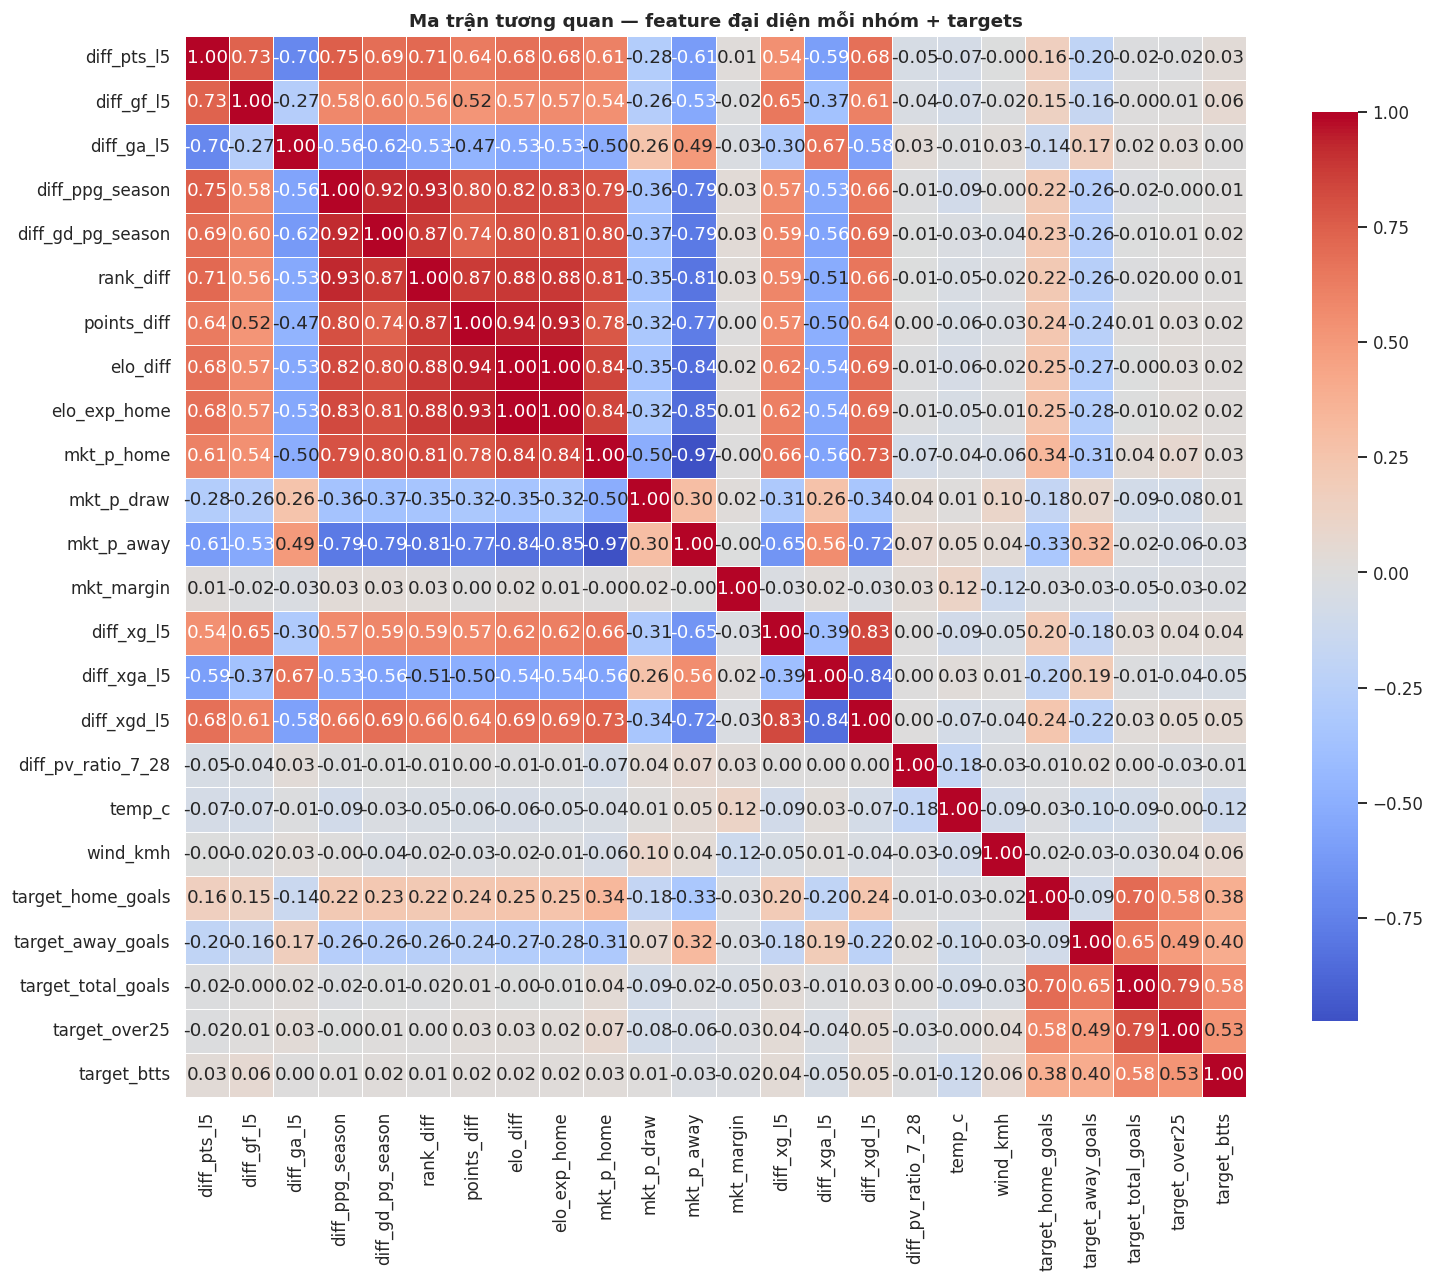

In [37]:
key_numeric_cols = [
    # form
    "diff_pts_l5", "diff_gf_l5", "diff_ga_l5", "diff_ppg_season", "diff_gd_pg_season",
    # position
    "rank_diff", "points_diff",
    # elo
    "elo_diff", "elo_exp_home",
    # market
    "mkt_p_home", "mkt_p_draw", "mkt_p_away", "mkt_margin",
    # xg
    "diff_xg_l5", "diff_xga_l5", "diff_xgd_l5",
    # attention
    "diff_pv_ratio_7_28",
    # context
    "temp_c", "wind_kmh",
    # targets (để xem tương quan feature -> target luôn)
    "target_home_goals", "target_away_goals", "target_total_goals", "target_over25", "target_btts",
]
key_numeric_cols = [c for c in key_numeric_cols if c in match_ml.columns]

corr_matrix = match_ml[key_numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Ma trận tương quan — feature đại diện mỗi nhóm + targets")
plt.tight_layout()
plt.show()


In [38]:
# Liệt kê các cặp feature có tương quan cao (|r| > 0.75) -> ứng viên đa cộng tuyến
pairs = []
cols = corr_matrix.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.75:
            pairs.append((cols[i], cols[j], round(r, 3)))

pairs_df = pd.DataFrame(pairs, columns=["feature_1", "feature_2", "correlation"]).sort_values(
    "correlation", key=abs, ascending=False)
print(f"Số cặp có |r| > 0.75: {len(pairs_df)}")
display(pairs_df)


Số cặp có |r| > 0.75: 30


,feature_1,feature_2,correlation
21,elo_diff,elo_exp_home,0.996
26,mkt_p_home,mkt_p_away,-0.974
17,points_diff,elo_diff,0.940
18,points_diff,elo_exp_home,0.931
1,diff_ppg_season,rank_diff,0.928
0,diff_ppg_season,diff_gd_pg_season,0.920
14,rank_diff,elo_exp_home,0.882
13,rank_diff,elo_diff,0.878
12,rank_diff,points_diff,0.873
7,diff_gd_pg_season,rank_diff,0.871


**VIF (Variance Inflation Factor)** — chỉ số định lượng đa cộng tuyến chặt chẽ hơn so với xem cặp đôi
(VIF > 5-10 thường được coi là đáng lo ngại).

In [39]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_input = match_ml[key_numeric_cols].drop(
    columns=["target_home_goals", "target_away_goals", "target_total_goals", "target_over25", "target_btts"]
).dropna()

vif_df = pd.DataFrame({
    "feature": vif_input.columns,
    "VIF": [variance_inflation_factor(vif_input.values, i) for i in range(vif_input.shape[1])],
}).sort_values("VIF", ascending=False)

display(vif_df)


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stat

,feature,VIF
13,diff_xg_l5,1.000800e+15
10,mkt_p_draw,1.000800e+15
9,mkt_p_home,1.000800e+15
15,diff_xgd_l5,1.000800e+15
14,diff_xga_l5,1.000800e+15
11,mkt_p_away,1.000800e+15
7,elo_diff,2.286497e+02
8,elo_exp_home,2.201280e+02
3,diff_ppg_season,1.318466e+01
5,rank_diff,1.034845e+01


## 13. So sánh sơ bộ sức mạnh dự đoán: Market vs Elo vs Form

So sánh nhanh (không phải huấn luyện model đầy đủ) mức độ mỗi nhóm tín hiệu "đoán đúng" kết quả trận đấu,
bằng cách quy đổi mỗi nhóm về một quy tắc dự đoán đơn giản (bên nào có tín hiệu tốt hơn -> dự đoán bên đó thắng).

,accuracy_H_vs_A,n_trận
Market odds,0.696270,563.0
Elo,0.662522,563.0
Form (ppg_season),0.636861,548.0
Vị trí BXH (points_diff),0.630551,563.0


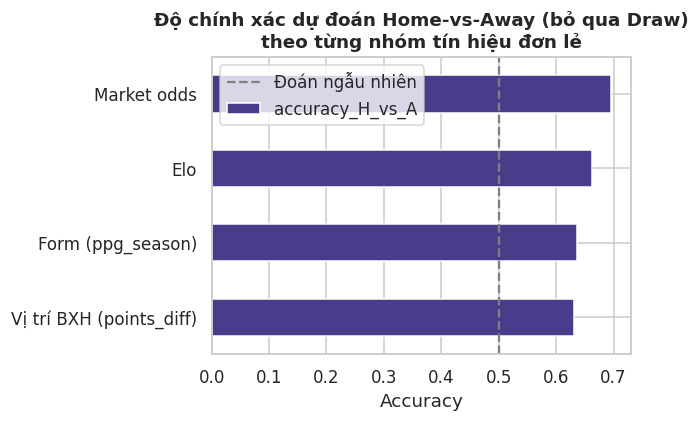

Lưu ý: đây chỉ là so sánh tín hiệu đơn lẻ (rule-of-thumb), không phải hiệu năng model thực tế.


In [40]:
def simple_accuracy(pred_favors_home, actual):
    """pred_favors_home: True nếu tín hiệu nghiêng về đội nhà thắng."""
    pred = np.where(pred_favors_home, "H", "A")
    mask = actual.isin(["H", "A"])  # bỏ qua trận hòa để so công bằng giữa các tín hiệu nhị phân
    return (pred[mask] == actual[mask]).mean(), mask.sum()

results = {}

sub = match_ml.dropna(subset=["mkt_p_home", "mkt_p_away"])
acc, n = simple_accuracy(sub["mkt_p_home"] > sub["mkt_p_away"], sub["target"])
results["Market odds"] = (acc, n)

sub = match_ml.dropna(subset=["elo_diff"])
acc, n = simple_accuracy(sub["elo_diff"] > 0, sub["target"])
results["Elo"] = (acc, n)

sub = match_ml.dropna(subset=["diff_ppg_season"])
acc, n = simple_accuracy(sub["diff_ppg_season"] > 0, sub["target"])
results["Form (ppg_season)"] = (acc, n)

sub = match_ml.dropna(subset=["points_diff"])
acc, n = simple_accuracy(sub["points_diff"] > 0, sub["target"])
results["Vị trí BXH (points_diff)"] = (acc, n)

res_df = pd.DataFrame(results, index=["accuracy_H_vs_A", "n_trận"]).T
display(res_df)

fig, ax = plt.subplots(figsize=(6, 4))
res_df["accuracy_H_vs_A"].sort_values().plot(kind="barh", ax=ax, color="darkslateblue")
ax.axvline(0.5, color="gray", linestyle="--", label="Đoán ngẫu nhiên")
ax.set_title("Độ chính xác dự đoán Home-vs-Away (bỏ qua Draw)\ntheo từng nhóm tín hiệu đơn lẻ")
ax.set_xlabel("Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

print("Lưu ý: đây chỉ là so sánh tín hiệu đơn lẻ (rule-of-thumb), không phải hiệu năng model thực tế.")


## 14. Phân tích theo đội bóng (team-level)

Dùng `feature_team_match` + `feature_team_xg` (Grain 1 dòng/đội/trận) để tổng hợp góc nhìn theo đội,
tương tự những gì `mart_team` sẽ phục vụ ở tầng Data Mart.

In [41]:
team_summary = (
    team_match.groupby("team_key")
    .agg(
        so_tran=("match_id", "count"),
        ppg_season_cuoi=("ppg_season", "last"),
        gd_pg_season_cuoi=("gd_pg_season", "last"),
        pts_l5_tb=("pts_l5", "mean"),
        gf_l5_tb=("gf_l5", "mean"),
        ga_l5_tb=("ga_l5", "mean"),
    )
    .sort_values("ppg_season_cuoi", ascending=False)
)
display(team_summary.head(15))


,so_tran,ppg_season_cuoi,gd_pg_season_cuoi,pts_l5_tb,gf_l5_tb,ga_l5_tb
team_key,,,,,,
Arsenal,76,2.194444,1.166667,2.075111,1.852889,0.802444
Manchester City,76,2.138889,1.194444,2.013333,1.983333,1.017556
Manchester United,76,1.837838,0.432432,1.456000,1.438889,1.372222
Aston Villa,76,1.638889,0.111111,1.727333,1.470444,1.303111
Liverpool,76,1.594595,0.270270,1.968667,1.979778,1.171333
Bournemouth,76,1.527778,0.111111,1.470889,1.524222,1.333111
Brighton,76,1.472222,0.277778,1.561778,1.602667,1.342222
Brentford,76,1.416667,0.083333,1.472000,1.602222,1.423111
Chelsea,76,1.405405,0.189189,1.597111,1.620444,1.246889


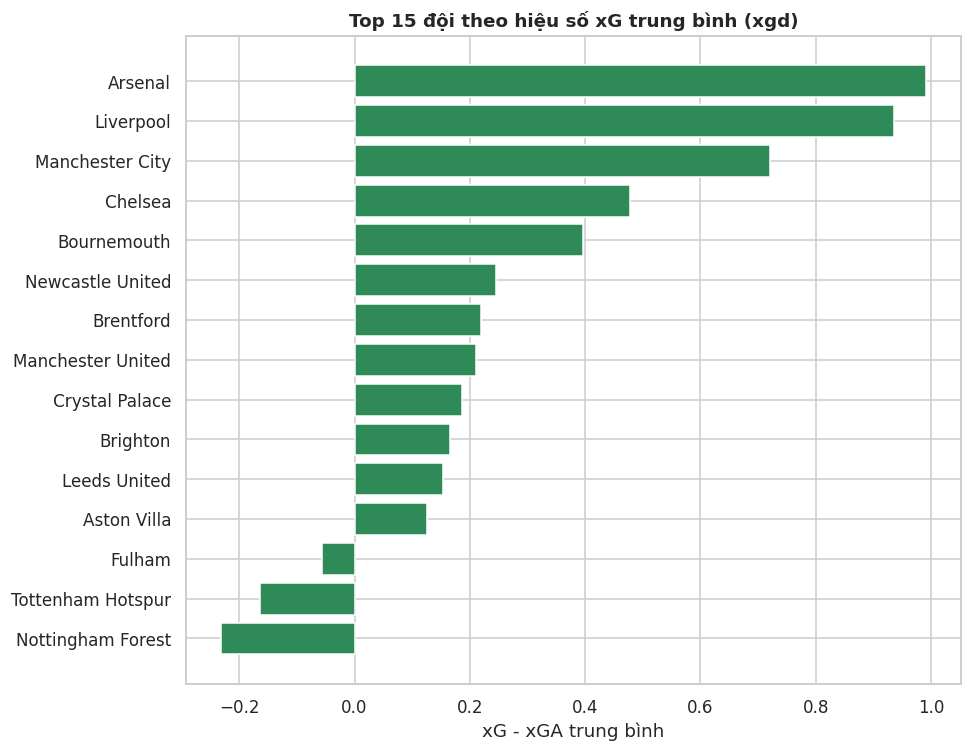

In [42]:
xg_summary = (
    team_xg.groupby("team_key")
    .agg(xg_tb=("xg_l5", "mean"), xga_tb=("xga_l5", "mean"), xgd_tb=("xgd_l5", "mean"))
    .sort_values("xgd_tb", ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 7))
top15 = xg_summary.head(15)
ax.barh(top15.index, top15["xgd_tb"], color="seagreen")
ax.invert_yaxis()
ax.set_title("Top 15 đội theo hiệu số xG trung bình (xgd)")
ax.set_xlabel("xG - xGA trung bình")
plt.tight_layout()
plt.show()


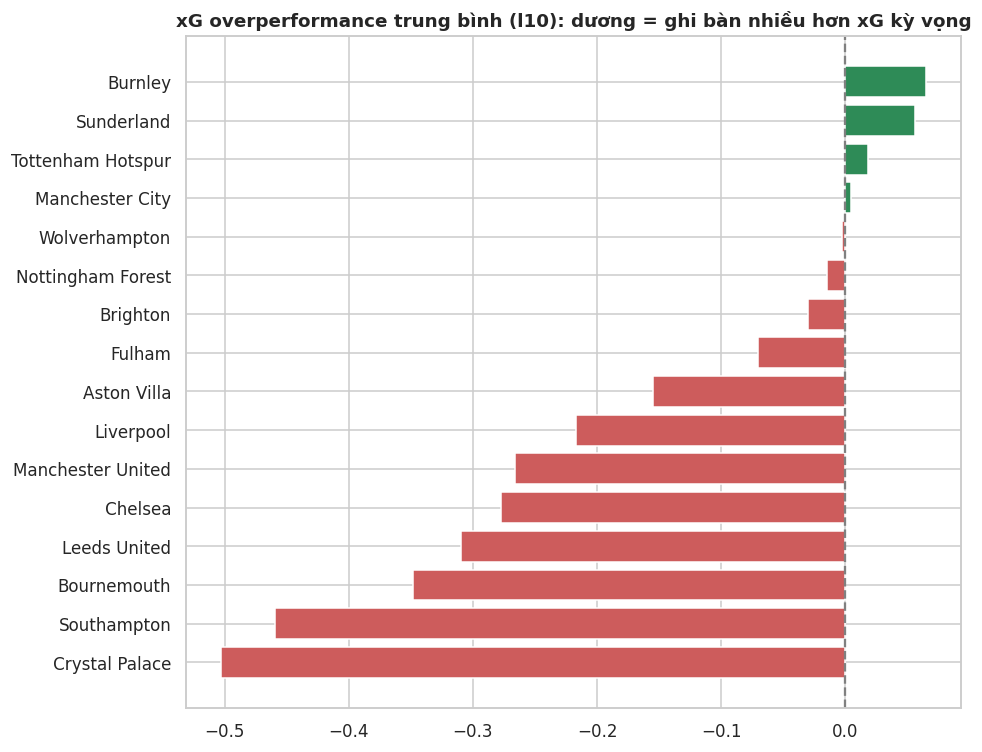

In [43]:
# So sánh xG tạo ra vs bàn thắng thực tế ghi được -> đội nào đang "may mắn"/"kém may mắn"
overperf = (
    team_xg.groupby("team_key")["xg_overperf_l10"].mean().sort_values(ascending=False)
)
fig, ax = plt.subplots(figsize=(9, 7))
top_bottom = pd.concat([overperf.head(8), overperf.tail(8)])
colors = ["seagreen" if v > 0 else "indianred" for v in top_bottom.values]
ax.barh(top_bottom.index, top_bottom.values, color=colors)
ax.axvline(0, color="gray", linestyle="--")
ax.invert_yaxis()
ax.set_title("xG overperformance trung bình (l10): dương = ghi bàn nhiều hơn xG kỳ vọng")
plt.tight_layout()
plt.show()


## 15. Diễn biến bảng xếp hạng theo thời gian

Ghép `feature_league_position` với ngày thi đấu (từ `feature_team_match`) để vẽ đường đi thứ hạng
của một vài đội tiêu biểu qua mùa giải.

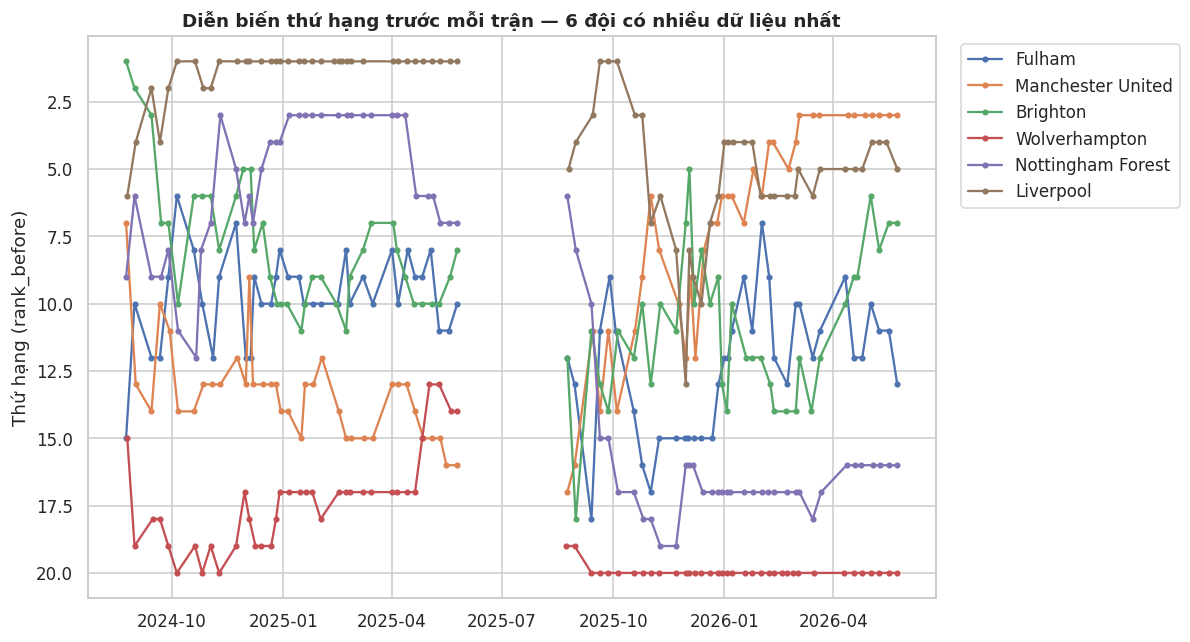

In [44]:
pos_with_date = league_pos.merge(
    team_match[["match_id", "team_key", "match_date"]], on=["match_id", "team_key"], how="left"
).dropna(subset=["match_date"]).sort_values("match_date")

# Chọn 6 đội có nhiều dữ liệu nhất để vẽ minh hoạ
top_teams = pos_with_date["team_key"].value_counts().head(6).index.tolist()

fig, ax = plt.subplots(figsize=(11, 6))
for t in top_teams:
    d = pos_with_date[pos_with_date["team_key"] == t]
    ax.plot(d["match_date"], d["rank_before"], marker="o", markersize=3, label=t)

ax.invert_yaxis()  # rank 1 ở trên cùng
ax.set_title("Diễn biến thứ hạng trước mỗi trận — 6 đội có nhiều dữ liệu nhất")
ax.set_ylabel("Thứ hạng (rank_before)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 16. Data Quality Summary & khuyến nghị

Tổng hợp lại các điểm cần lưu ý trước khi đưa dữ liệu vào huấn luyện model:

In [45]:
summary_points = []

n_matches = len(match_ml)
n_divisions = match_ml["division"].nunique()
n_seasons = match_ml["season"].nunique()
weather_missing = match_ml["temp_c"].isna().mean()
odds_missing = match_ml["pin_p_home"].isna().mean()
early_season_missing = match_ml[match_ml["home_n_prior_season"] < 5]["home_pts_l5"].isna().mean()

summary_points.append(f"- Kích thước mẫu: {n_matches} trận, {n_divisions} giải đấu ({match_ml['division'].unique()[0]}), "
                       f"{n_seasons} mùa giải -> khá nhỏ, cần cẩn trọng với overfitting và độ tin cậy thống kê.")
summary_points.append(f"- Thiếu dữ liệu thời tiết ở {weather_missing:.0%} số trận -> cân nhắc loại bỏ nhóm context "
                       f"thời tiết khỏi model chính, hoặc coi 'missing' là một category riêng.")
summary_points.append(f"- Thiếu dữ liệu Pinnacle odds ở {odds_missing:.0%} số trận -> nếu dùng pin_* làm feature "
                       f"chính cần xử lý missing (impute bằng mkt_* hoặc bỏ dòng).")
summary_points.append(f"- Với các trận trong 5 vòng đầu mùa, feature phong độ 'l5' gần như luôn missing "
                       f"({early_season_missing:.0%}) — đúng theo thiết kế chống leakage, nhưng cần chiến lược "
                       f"impute/loại trừ rõ ràng khi huấn luyện.")
summary_points.append("- Elo bắt đầu đồng nhất ở mức 1500 cho tất cả đội vào đầu mùa đầu tiên trong dữ liệu "
                       "-> elo_diff = 0 ở giai đoạn này làm giảm giá trị dự đoán của Elo cho các trận đầu mùa 2024-25.")
summary_points.append("- Dữ liệu chỉ có 1 giải đấu (E0 - Premier League) -> model huấn luyện trên dữ liệu này "
                       "khó tổng quát hoá sang giải đấu khác nếu không có thêm dữ liệu.")
summary_points.append("- Cột 'split' chỉ có 2 giá trị (valid/test, không có 'train' tường minh) -> cần làm rõ "
                       "quy ước train/valid/test trước khi huấn luyện, đặc biệt với time-series (nên split theo "
                       "thời gian, không random-split, để tránh leakage từ tương lai về quá khứ).")

for p in summary_points:
    print(p)


- Kích thước mẫu: 760 trận, 1 giải đấu (E0), 2 mùa giải -> khá nhỏ, cần cẩn trọng với overfitting và độ tin cậy thống kê.
- Thiếu dữ liệu thời tiết ở 60% số trận -> cân nhắc loại bỏ nhóm context thời tiết khỏi model chính, hoặc coi 'missing' là một category riêng.
- Thiếu dữ liệu Pinnacle odds ở 22% số trận -> nếu dùng pin_* làm feature chính cần xử lý missing (impute bằng mkt_* hoặc bỏ dòng).
- Với các trận trong 5 vòng đầu mùa, feature phong độ 'l5' gần như luôn missing (12%) — đúng theo thiết kế chống leakage, nhưng cần chiến lược impute/loại trừ rõ ràng khi huấn luyện.
- Elo bắt đầu đồng nhất ở mức 1500 cho tất cả đội vào đầu mùa đầu tiên trong dữ liệu -> elo_diff = 0 ở giai đoạn này làm giảm giá trị dự đoán của Elo cho các trận đầu mùa 2024-25.
- Dữ liệu chỉ có 1 giải đấu (E0 - Premier League) -> model huấn luyện trên dữ liệu này khó tổng quát hoá sang giải đấu khác nếu không có thêm dữ liệu.
- Cột 'split' chỉ có 2 giá trị (valid/test, không có 'train' tường minh) -> cần làm rõ qu

## 17. Kết luận

Bộ dữ liệu `gold/features` hiện có đầy đủ các nhóm tín hiệu chính để dự đoán bóng đá:
**phong độ (form), vị trí BXH (position), sức mạnh đội bóng (Elo), kỳ vọng thị trường (market odds),
chất lượng cơ hội (xG), mức độ chú ý truyền thông (attention)** và **bối cảnh trận đấu (context/thời tiết)**.

Những điểm nổi bật từ EDA:

- **Market odds** thường có khả năng phân biệt kết quả tốt nhất trong số các tín hiệu đơn lẻ (đã bao hàm
  thông tin đội hình, chấn thương... mà các nhóm feature khác chưa nắm được).
- **Elo** và **Form** bổ sung thông tin có ích nhưng còn nhiễu ở giai đoạn đầu mùa giải do thiếu lịch sử.
- **xG** cho thấy tương quan dương với bàn thắng thực tế trận tiếp theo, xác nhận đây là tín hiệu chất lượng
  cao hơn so với chỉ dùng số bàn thắng thô (gf_l5) vì loại bỏ được yếu tố may rủi ngắn hạn.
- **Attention (pageviews)** là tín hiệu yếu hơn, mang tính bổ trợ (proxy cho các sự kiện bất thường) hơn là
  tín hiệu dự đoán chính.
- **Thời tiết** có tỷ lệ missing cao, cần cân nhắc kỹ trước khi đưa vào model chính thức.

Danh sách chi tiết các **bài toán Machine Learning** có thể áp dụng lên bộ dữ liệu này (không cần code)
được trình bày riêng trong phần trả lời của trợ lý.
